In [3]:
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
#pandas.set_option('max_colwidth', -1)
pd.set_option('display.precision', 3)

# Data understanding

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#------------------------------------------------------------
# 1. CARGA DEL DATASET
# ------------------------------------------------------------
df_raw = pd.read_csv("/content/Global Missing Migrants Dataset.csv",
                     sep=",", na_values=".")

print("Shape inicial:", df_raw.shape)

# ------------------------------------------------------------
# 2. INFORMACIÓN GENERAL
# ------------------------------------------------------------
print("\n--- INFO DE COLUMNAS ---")
df_raw.info()

print("\n--- VALORES FALTANTES ---")
print(df_raw.isnull().sum())

Shape inicial: (13020, 19)

--- INFO DE COLUMNAS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13020 entries, 0 to 13019
Data columns (total 19 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Incident Type                        13020 non-null  object 
 1   Incident year                        13020 non-null  int64  
 2   Reported Month                       13020 non-null  object 
 3   Region of Origin                     12998 non-null  object 
 4   Region of Incident                   13020 non-null  object 
 5   Country of Origin                    13012 non-null  object 
 6   Number of Dead                       12470 non-null  float64
 7   Minimum Estimated Number of Missing  13020 non-null  int64  
 8   Total Number of Dead and Missing     13020 non-null  int64  
 9   Number of Survivors                  13020 non-null  int64  
 10  Number of Females                    1302

In [ ]:
df_raw.duplicated().sum()

np.int64(641)

In [ ]:
# ------------------------------------------------------------
# 3. ESTADÍSTICAS DESCRIPTIVAS
# ------------------------------------------------------------
print("\n--- DESCRIPTIVE STATISTICS (NUMERIC) ---")
print(df_raw.describe())


--- DESCRIPTIVE STATISTICS (NUMERIC) ---
       Incident year  Number of Dead  Minimum Estimated Number of Missing  Total Number of Dead and Missing  Number of Survivors  Number of Females  Number of Males  Number of Children
count      13020.000       12470.000                            13020.000                         13020.000            13020.000          13020.000        13020.000           13020.000
mean        2019.061           2.624                                1.904                             4.417                6.554              0.458            1.116               0.238
std            2.419           9.728                               15.645                            19.951               42.315              2.854            3.811               2.417
min         2014.000           0.000                               -2.000                             1.000               -2.000              0.000            0.000               0.000
25%         2017.000           1.

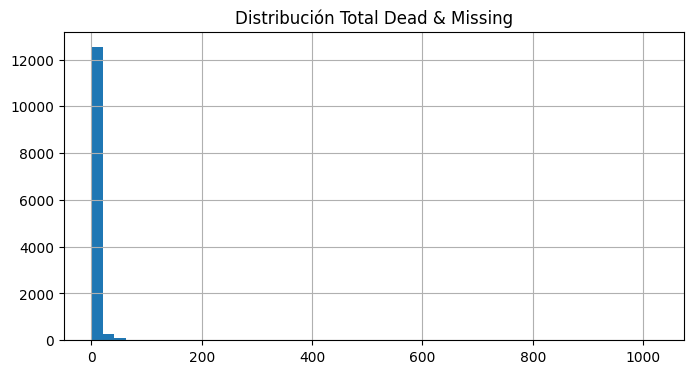

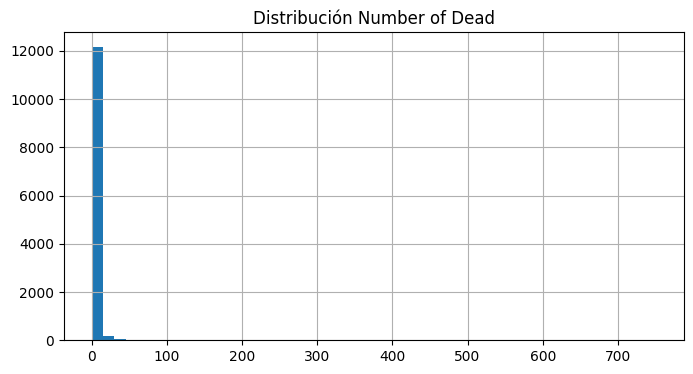

In [ ]:
# ------------------------------------------------------------
# 4. DISTRIBUCIONES DE VARIABLES CLAVE
# ------------------------------------------------------------

df_raw["Total Number of Dead and Missing"].hist(bins=50, figsize=(8,4))
plt.title("Distribución Total Dead & Missing")
plt.show()

df_raw["Number of Dead"].hist(bins=50, figsize=(8,4))
plt.title("Distribución Number of Dead")
plt.show()

In [ ]:
# ------------------------------------------------------------
# 5. CARDINALIDAD DE CATEGÓRICAS
# ------------------------------------------------------------
categorical_cols = df_raw.select_dtypes(include="object").columns

print("\n--- CARDINALIDAD DE CATEGÓRICAS ---")
for col in categorical_cols:
    print(f"{col}: {df_raw[col].nunique()} categorías")


--- CARDINALIDAD DE CATEGÓRICAS ---
Incident Type: 4 categorías
Reported Month: 12 categorías
Region of Origin: 33 categorías
Region of Incident: 16 categorías
Country of Origin: 335 categorías
Cause of Death: 15 categorías
Migration route: 25 categorías
Location of death: 7460 categorías
Information Source: 3803 categorías
Coordinates: 9582 categorías
UNSD Geographical Grouping: 19 categorías


In [ ]:
# ------------------------------------------------------------
# 6. RANGOS INICIALES DE VARIABLES NUMÉRICAS
# ------------------------------------------------------------
numeric_cols = df_raw.select_dtypes(include=["int64","float64"]).columns

print("\n--- RANGO DE VARIABLES NUMÉRICAS ---")
for col in numeric_cols:
    print(col,
          "min:", df_raw[col].min(),
          "max:", df_raw[col].max())


--- RANGO DE VARIABLES NUMÉRICAS ---
Incident year min: 2014 max: 2023
Number of Dead min: 0.0 max: 750.0
Minimum Estimated Number of Missing min: -2 max: 750
Total Number of Dead and Missing min: 1 max: 1022
Number of Survivors min: -2 max: 1950
Number of Females min: 0 max: 94
Number of Males min: 0 max: 135
Number of Children min: 0 max: 250


In [ ]:
# ------------------------------------------------------------
# 7. DETECCIÓN INICIAL DE OUTLIERS (IQR)
# ------------------------------------------------------------
print("\n--- OUTLIERS INICIALES (solo inspección) ---")

outlier_count = {}

for col in numeric_cols:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    count = df_raw[(df_raw[col] < lower) | (df_raw[col] > upper)].shape[0]
    outlier_count[col] = count

outlier_count


--- OUTLIERS INICIALES (solo inspección) ---


{'Incident year': 0,
 'Number of Dead': 1465,
 'Minimum Estimated Number of Missing': 1262,
 'Total Number of Dead and Missing': 2073,
 'Number of Survivors': 2061,
 'Number of Females': 2342,
 'Number of Males': 656,
 'Number of Children': 1573}

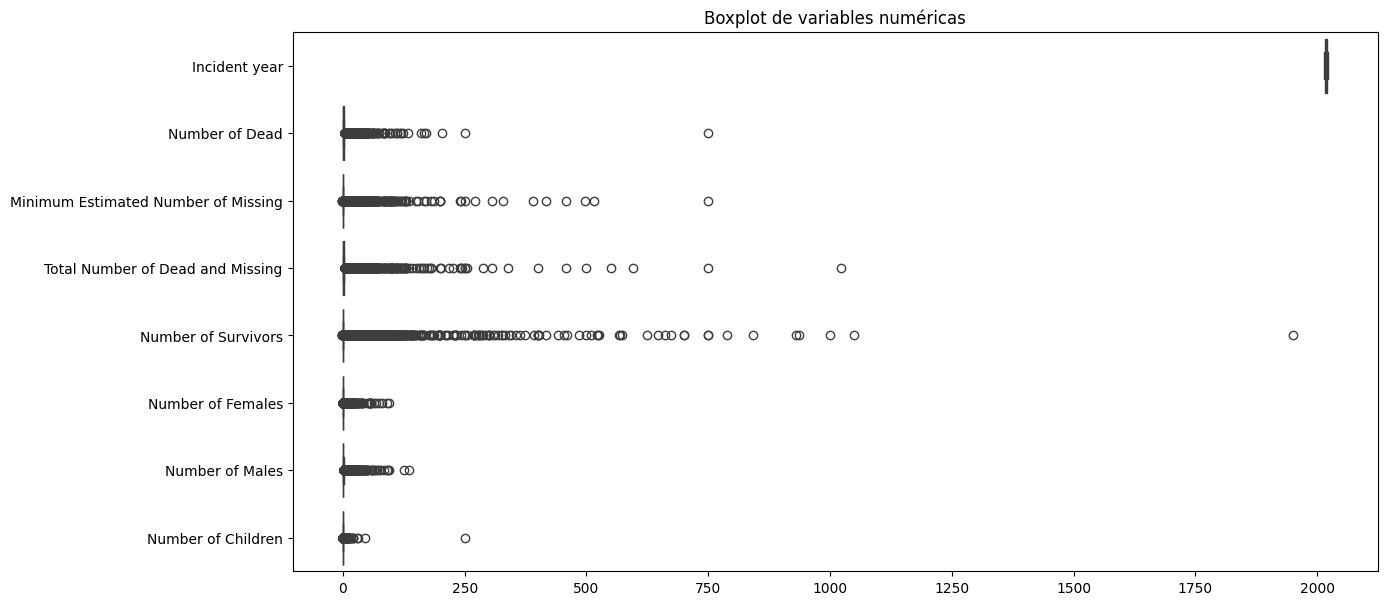

In [ ]:
# ------------------------------------------------------------
# 8. BOXPLOTS DE COLUMNAS NUMÉRICAS (visual)
# ------------------------------------------------------------
plt.figure(figsize=(14,7))
sns.boxplot(data=df_raw[numeric_cols], orient="h")
plt.title("Boxplot de variables numéricas")
plt.show()

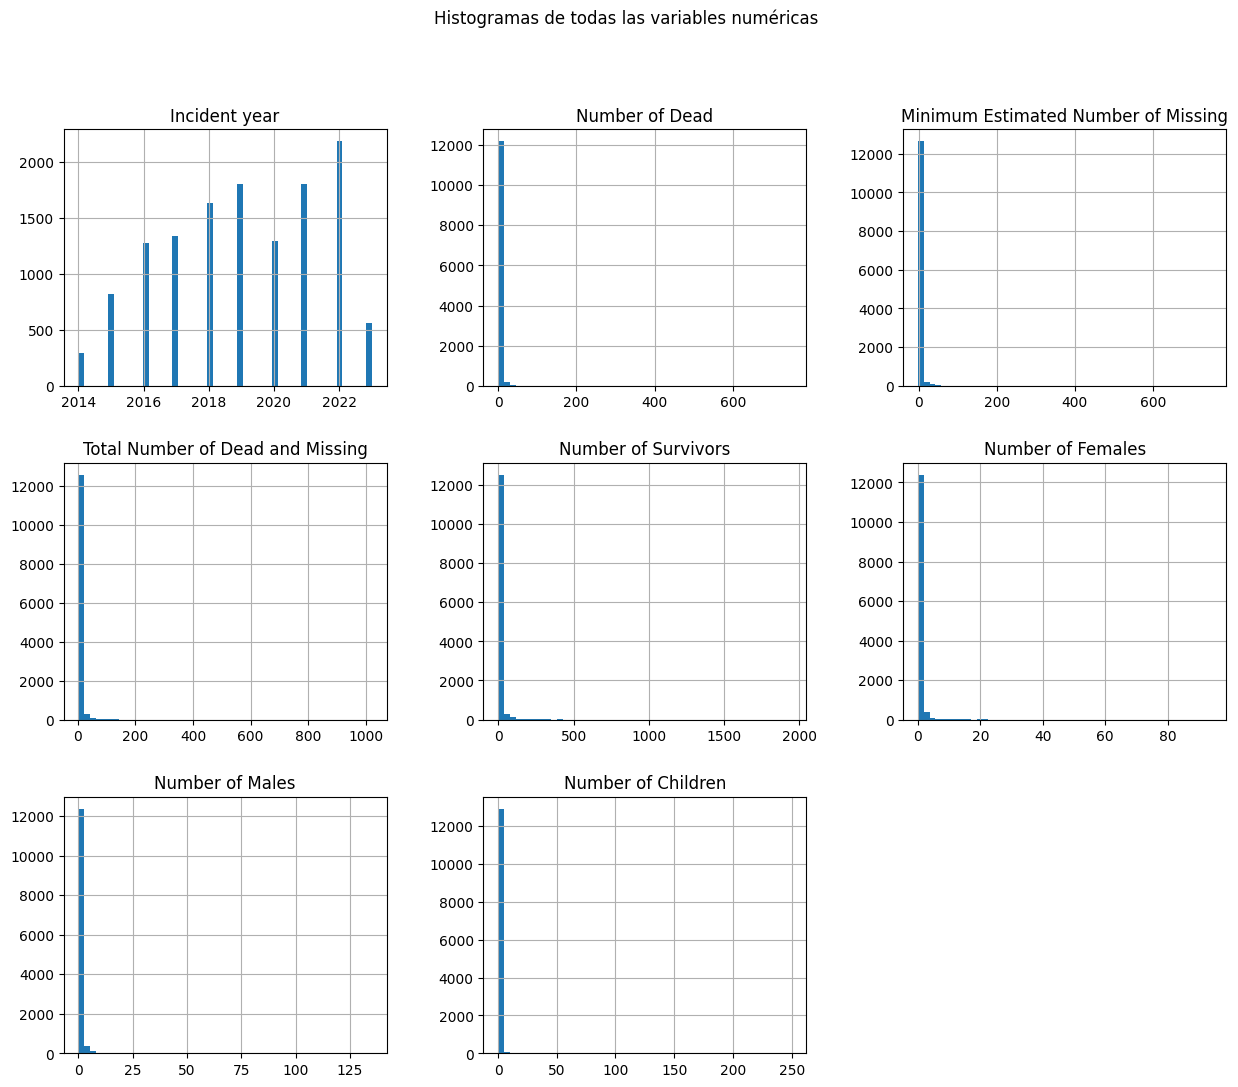

In [ ]:
# ------------------------------------------------------------
# 9. HISTOGRAMAS GLOBALes PARA ANALIZAR ASIMETRÍA
# ------------------------------------------------------------
df_raw[numeric_cols].hist(bins=50, figsize=(15,12))
plt.suptitle("Histogramas de todas las variables numéricas")
plt.show()


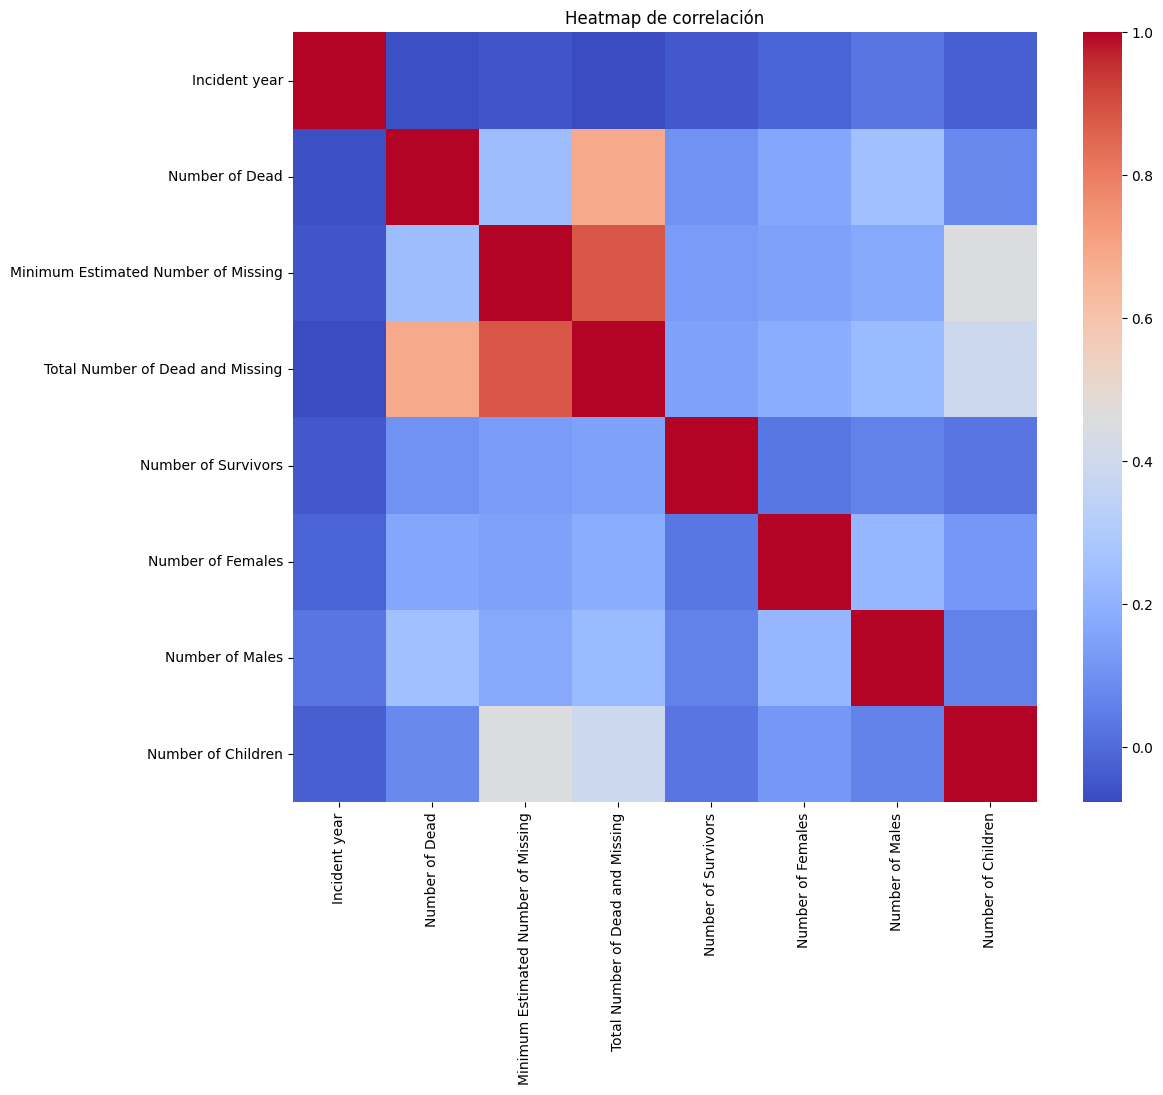

In [ ]:
# ------------------------------------------------------------
# 10. CORRELACIÓN ENTRE VARIABLES
# ------------------------------------------------------------
corr = df_raw[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Heatmap de correlación")
plt.show()

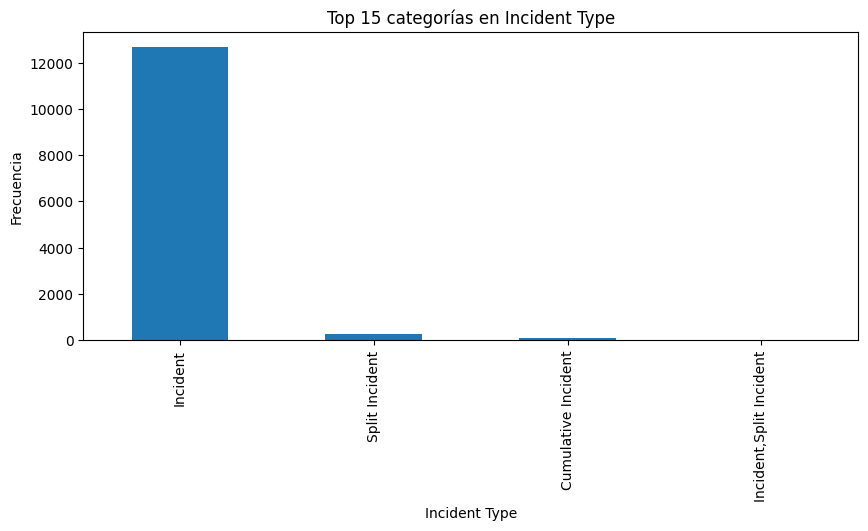

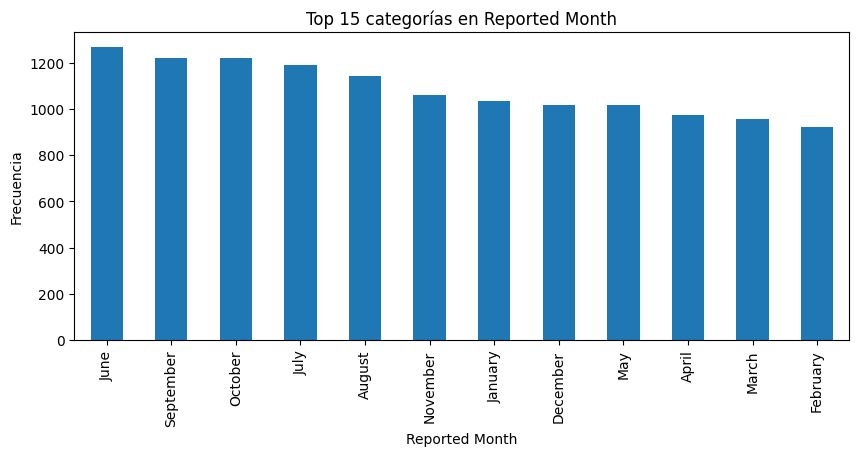

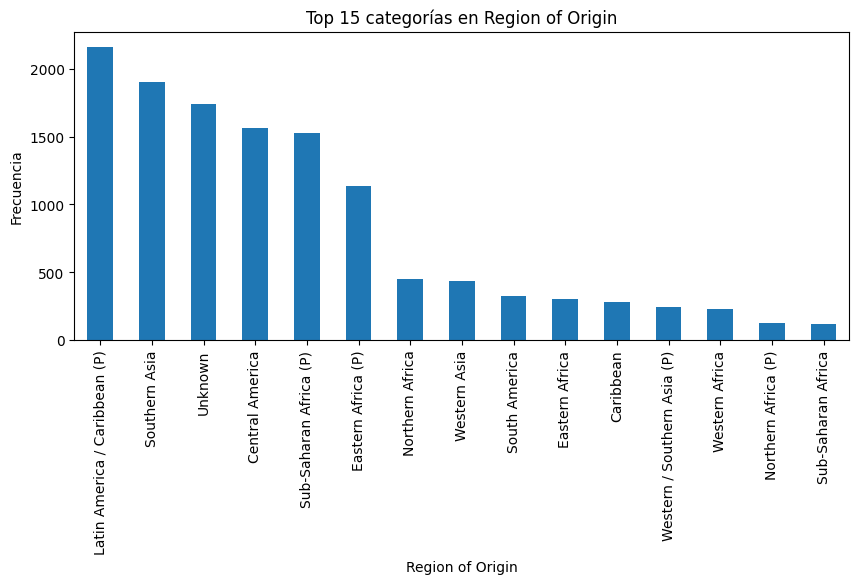

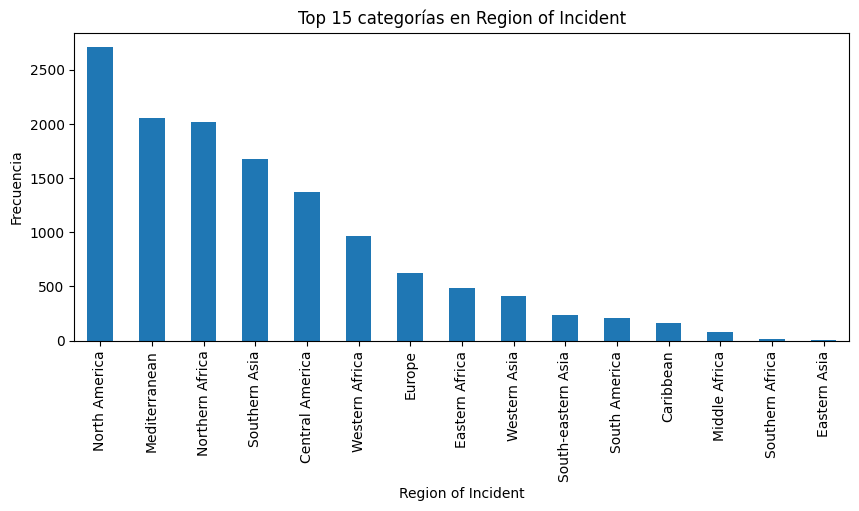

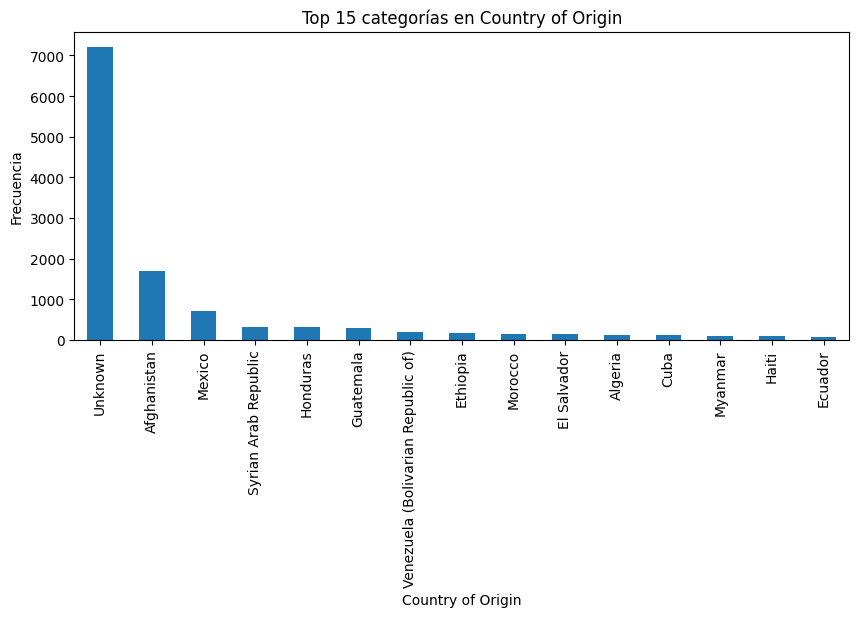

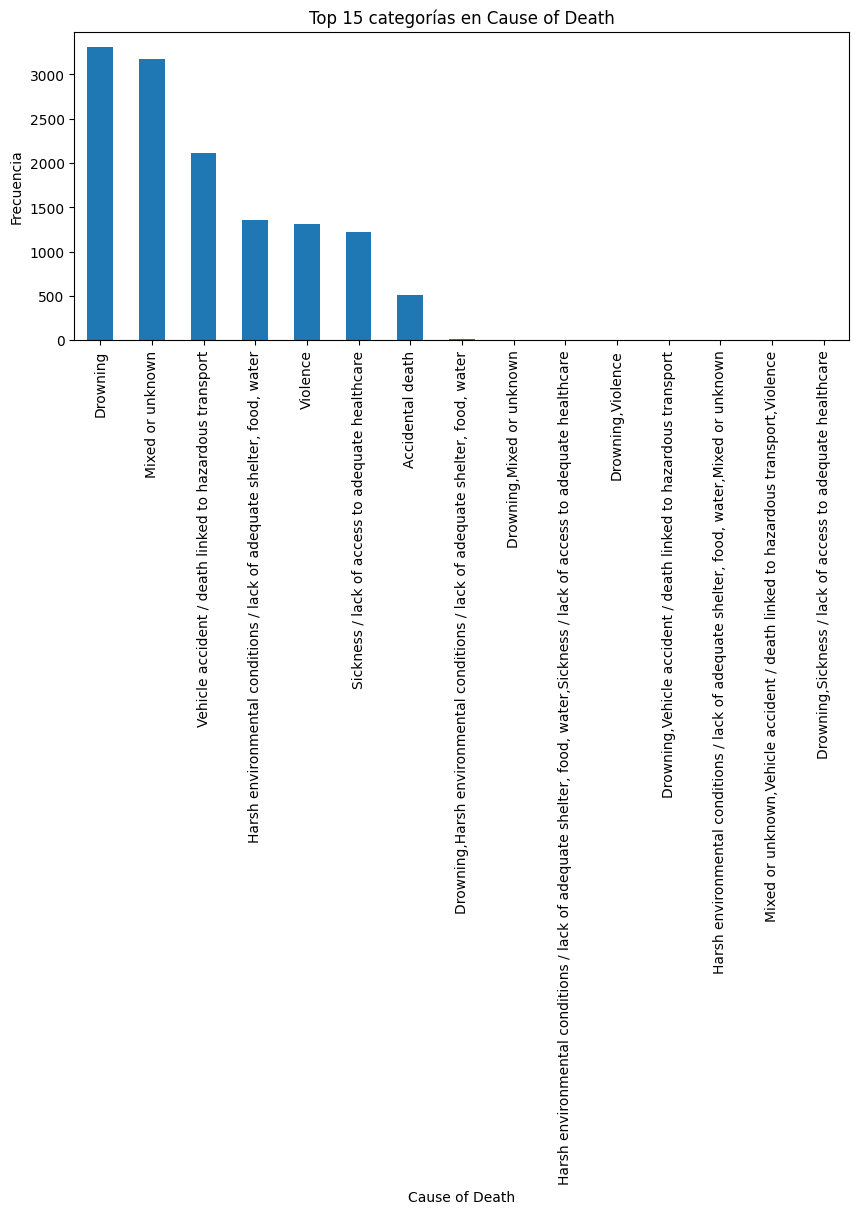

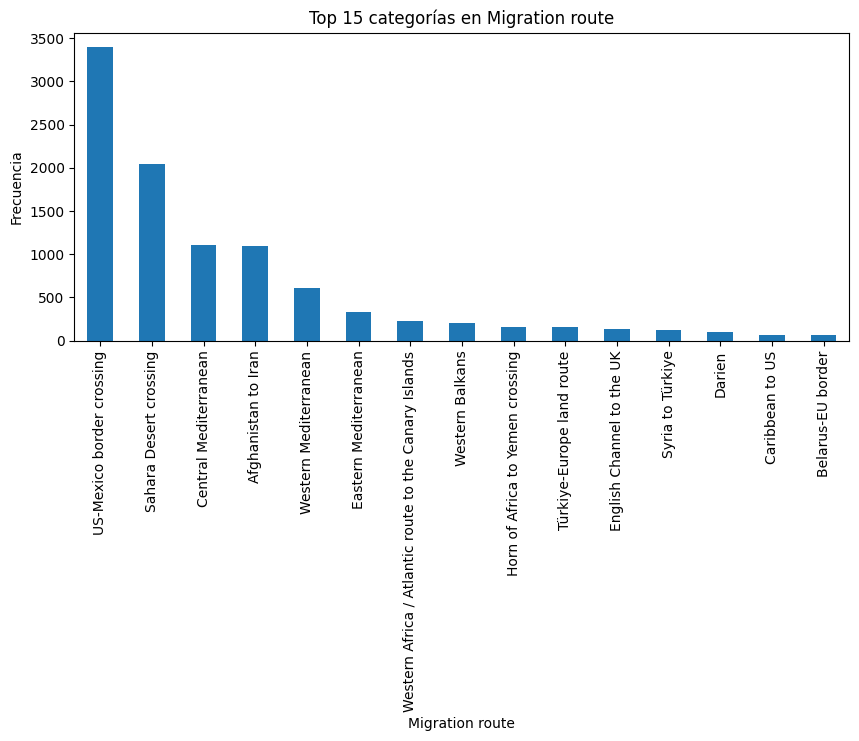

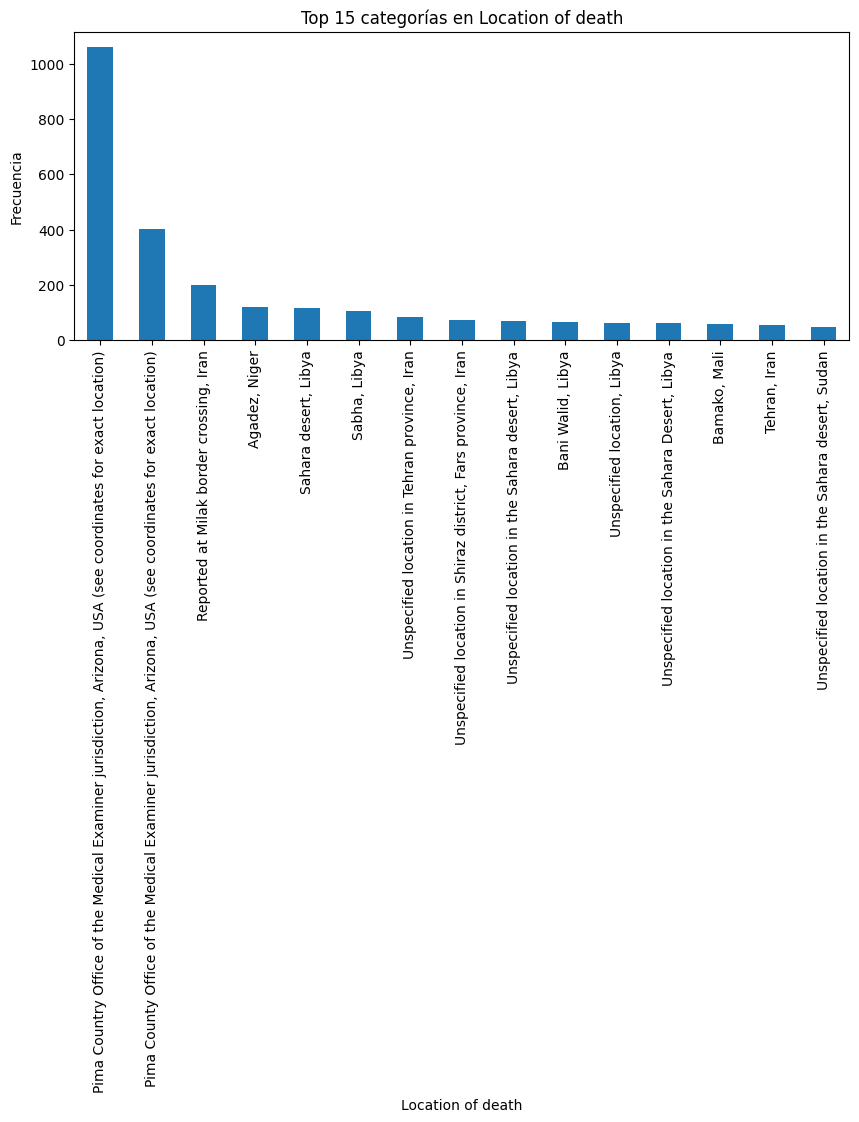

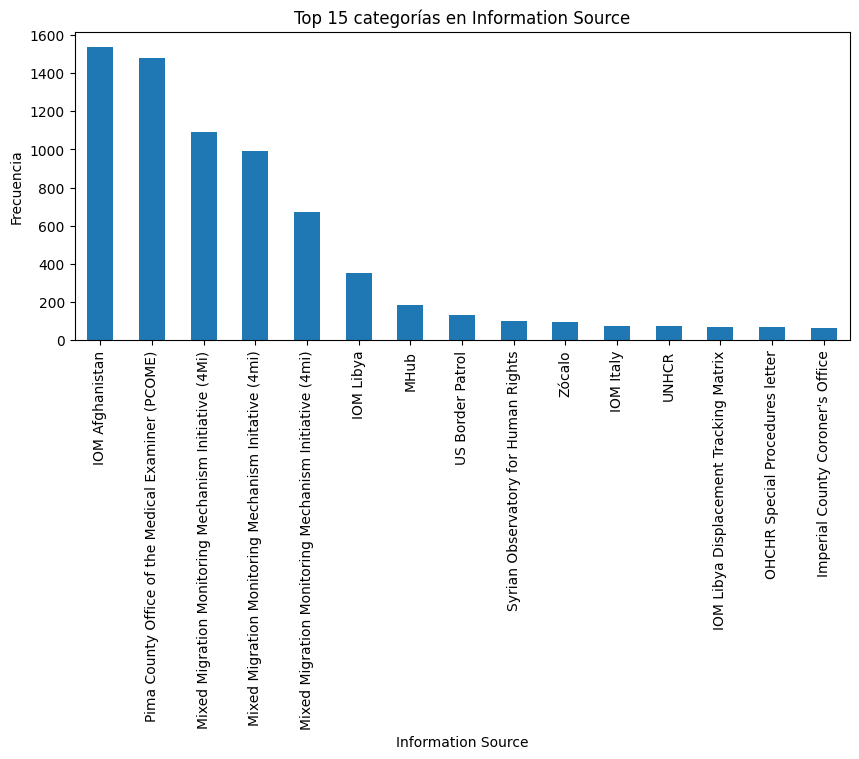

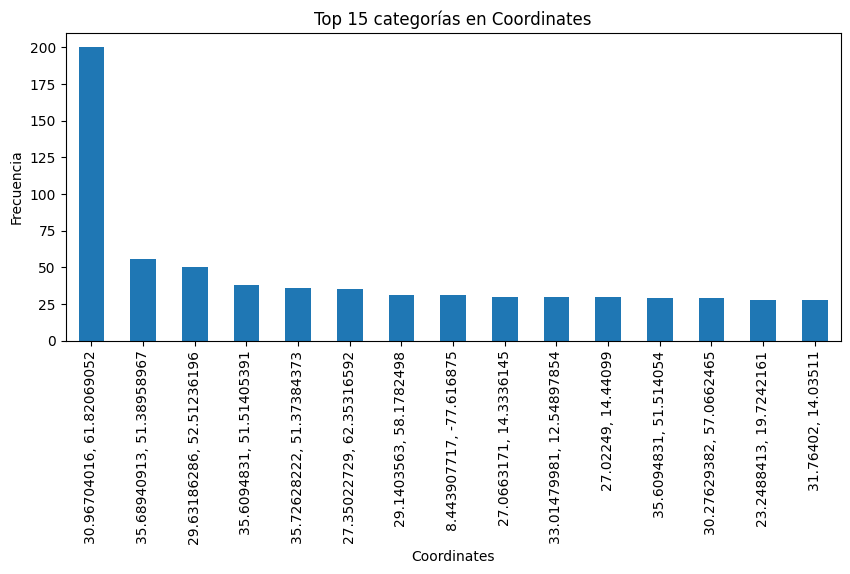

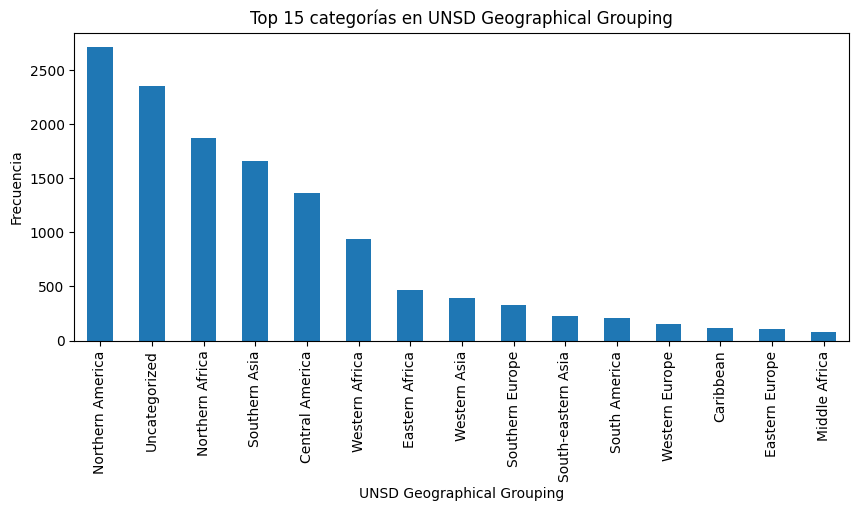

In [ ]:
# ------------------------------------------------------------
# 11. DISTRIBUCIÓN DE CATEGÓRICAS (Top 15)
# ------------------------------------------------------------
for col in categorical_cols:
    plt.figure(figsize=(10,4))
    df_raw[col].value_counts().head(15).plot(kind="bar")
    plt.title(f"Top 15 categorías en {col}")
    plt.ylabel("Frecuencia")
    plt.show()

In [ ]:
# ------------------------------------------------------------
# 12. SKEWNESS (asimetría) DE VARIABLES NUMÉRICAS
# ------------------------------------------------------------
print("\n--- SKEWNESS DE VARIABLES NUMÉRICAS ---")
print(df_raw[numeric_cols].skew())


--- SKEWNESS DE VARIABLES NUMÉRICAS ---
Incident year                          -0.214
Number of Dead                         41.798
Minimum Estimated Number of Missing    22.900
Total Number of Dead and Missing       23.702
Number of Survivors                    18.073
Number of Females                      17.841
Number of Males                        16.595
Number of Children                     85.978
dtype: float64


In [ ]:
# ------------------------------------------------------------
# 13. COORDENADAS (SIN SEPARAR)
# ------------------------------------------------------------
print("\n--- COORDENADAS INICIALES ---")
coord_na = df_raw["Coordinates"].isna().sum()
print("Coordinates sin datos:", coord_na)

coord_format = df_raw["Coordinates"].dropna().apply(lambda x: "," in x)
print("Coordenadas mal formateadas:", (~coord_format).sum())


--- COORDENADAS INICIALES ---
Coordinates sin datos: 36
Coordenadas mal formateadas: 0


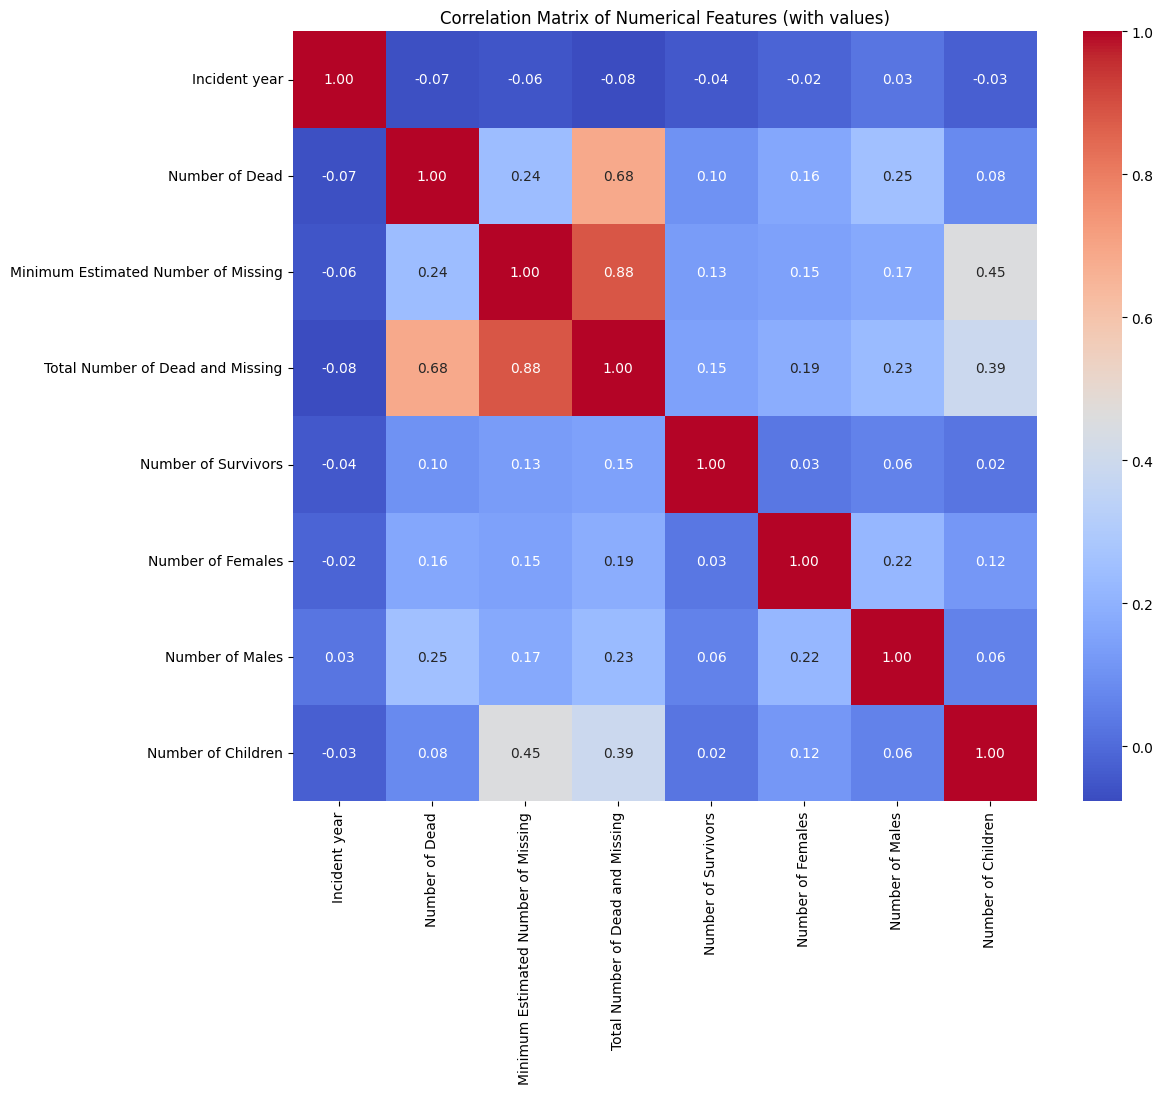

In [ ]:
numeric_cols = df_raw.select_dtypes(include=["float64", "int64"]).columns
numeric_corr = df_raw[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(numeric_corr, cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Matrix of Numerical Features (with values)")
plt.show()

In [ ]:
target = "Total Number of Dead and Missing"

corr_with_target = (
    df_raw[numeric_cols]
    .corr()[target]
    .sort_values(ascending=False)
)

print("=== Correlación con variable objetivo ===\n")
print(corr_with_target)

=== Correlación con variable objetivo ===

Total Number of Dead and Missing       1.000
Minimum Estimated Number of Missing    0.884
Number of Dead                         0.685
Number of Children                     0.392
Number of Males                        0.230
Number of Females                      0.186
Number of Survivors                    0.148
Incident year                         -0.077
Name: Total Number of Dead and Missing, dtype: float64


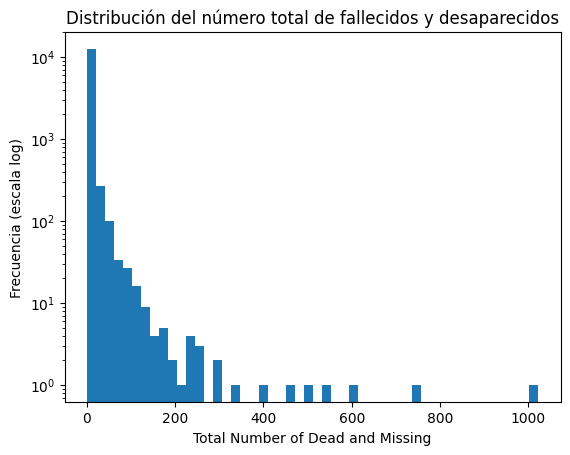

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.hist(df_raw["Total Number of Dead and Missing"], bins=50)
plt.yscale("log")
plt.xlabel("Total Number of Dead and Missing")
plt.ylabel("Frecuencia (escala log)")
plt.title("Distribución del número total de fallecidos y desaparecidos")
plt.show()

/tmp/ipython-input-902606520.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


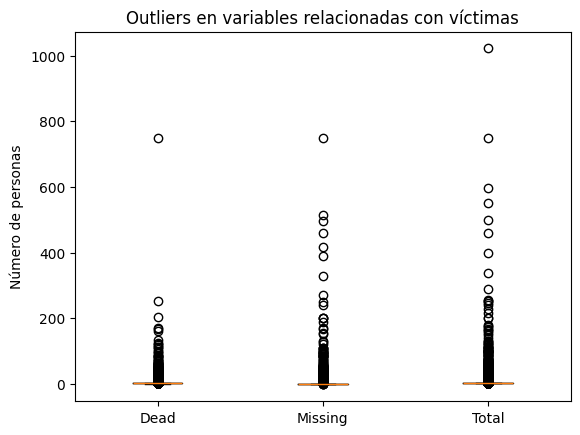

In [ ]:
plt.figure()
plt.boxplot(
    df_raw[[
        "Number of Dead",
        "Minimum Estimated Number of Missing",
        "Total Number of Dead and Missing"
    ]].dropna(),
    labels=["Dead", "Missing", "Total"]
)
plt.ylabel("Número de personas")
plt.title("Outliers en variables relacionadas con víctimas")
plt.show()

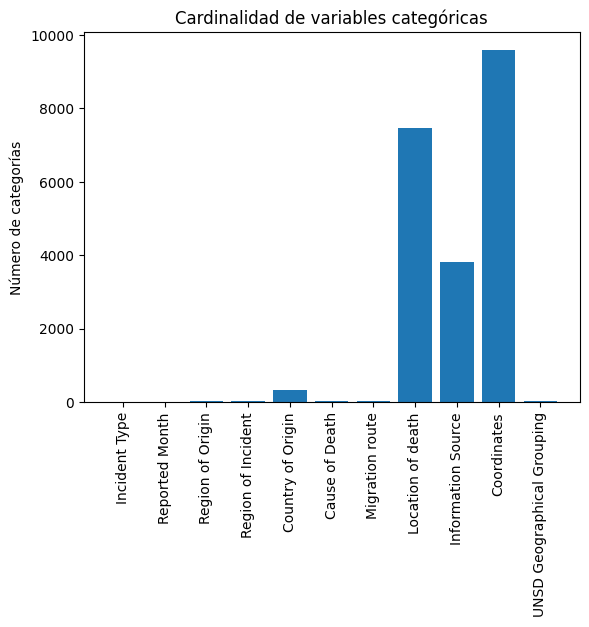

In [ ]:
categorical_cols = df_raw.select_dtypes(include="object").columns
cardinality = [df_raw[col].nunique() for col in categorical_cols]

plt.figure()
plt.bar(categorical_cols, cardinality)
plt.xticks(rotation=90)
plt.ylabel("Número de categorías")
plt.title("Cardinalidad de variables categóricas")
plt.show()

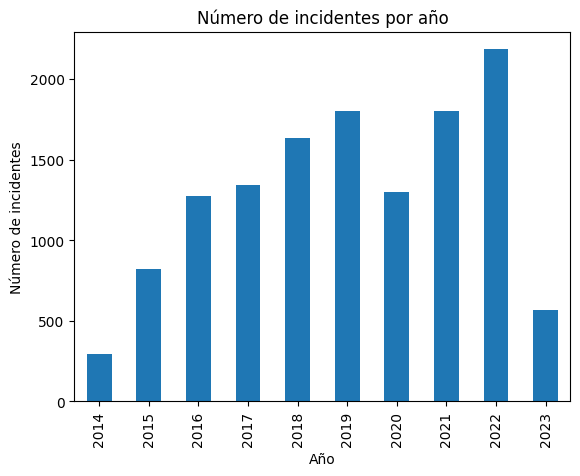

In [ ]:
plt.figure()
df_raw["Incident year"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Año")
plt.ylabel("Número de incidentes")
plt.title("Número de incidentes por año")
plt.show()

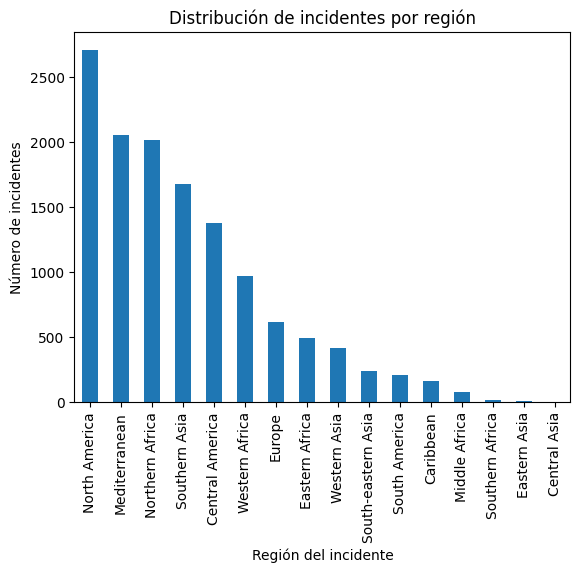

In [ ]:
plt.figure()
df_raw["Region of Incident"].value_counts().plot(kind="bar")
plt.xlabel("Región del incidente")
plt.ylabel("Número de incidentes")
plt.title("Distribución de incidentes por región")
plt.show()

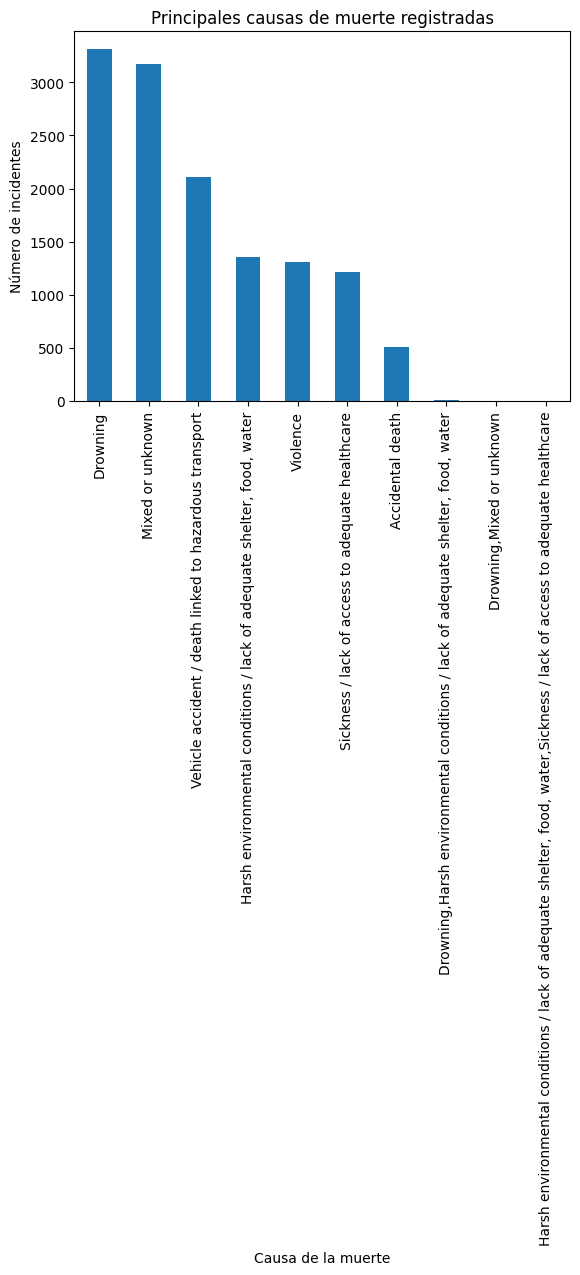

In [ ]:
plt.figure()
df_raw["Cause of Death"].value_counts().head(10).plot(kind="bar")
plt.xlabel("Causa de la muerte")
plt.ylabel("Número de incidentes")
plt.title("Principales causas de muerte registradas")
plt.show()

# Data cleaning


In [5]:
# ===========================================
# DATA CLEANING – Limpieza inicial del dataset
# ===========================================

import pandas as pd
import numpy as np

def clean_dataset(df):
    df = df.copy()

    # --------------------------
    # 1. Eliminar duplicados
    # --------------------------
    initial_rows = df.shape[0]
    df = df.drop_duplicates()
    print(f"Duplicados eliminados: {initial_rows - df.shape[0]}")

    # --------------------------
    # 2. Normalizar columnas numéricas
    # --------------------------
    numeric_cols = [
        "Number of Dead",
        "Minimum Estimated Number of Missing",
        "Total Number of Dead and Missing",
        "Number of Survivors",
        "Number of Females",
        "Number of Males",
        "Number of Children"
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

            # Reemplazar valores negativos por NaN
            neg = (df[col] < 0).sum()
            if neg > 0:
                df.loc[df[col] < 0, col] = np.nan
                print(f"Negativos corregidos en {col}: {neg}")

    # --------------------------
    # 3. Separar coordenadas
    # --------------------------
    def split_coords(coord):
        if isinstance(coord, str) and "," in coord:
            try:
                lat, lon = coord.split(",", 1)
                lat, lon = float(lat), float(lon)
                # Validación geográfica
                if not (-90 <= lat <= 90): lat = np.nan
                if not (-180 <= lon <= 180): lon = np.nan
                return lat, lon
            except:
                return np.nan, np.nan
        return np.nan, np.nan

    if "Coordinates" in df.columns:
        df["Latitude"], df["Longitude"] = zip(*df["Coordinates"].apply(split_coords))
        df.drop(columns=["Coordinates"], inplace=True)

    # --------------------------
    # 4. Reconstrucción segura del total Dead+Missing
    # --------------------------
    if ("Number of Dead" in df.columns) and ("Minimum Estimated Number of Missing" in df.columns):

        dead_tmp = df["Number of Dead"].fillna(0)
        miss_tmp = df["Minimum Estimated Number of Missing"].fillna(0)

        calculated_total = dead_tmp + miss_tmp

        df["Total Number of Dead and Missing"] = df[
            ["Total Number of Dead and Missing"]
        ].fillna(calculated_total)

        # Si el total es menor que dead+missing → corregirlo
        mask_inconsistent = df["Total Number of Dead and Missing"] < calculated_total
        if mask_inconsistent.sum() > 0:
            df.loc[mask_inconsistent, "Total Number of Dead and Missing"] = calculated_total[mask_inconsistent]
            print(f"Totales corregidos: {mask_inconsistent.sum()}")

    # --------------------------
    # 5. Eliminar filas imposibles
    #    (casos contradictorios)
    # --------------------------
    if {"Total Number of Dead and Missing", "Number of Dead", "Minimum Estimated Number of Missing"}.issubset(df.columns):
        impossible_mask = (
            (df["Total Number of Dead and Missing"] == 0)
            & ((df["Number of Dead"] > 0) | (df["Minimum Estimated Number of Missing"] > 0))
        )

        print(f"Filas imposibles eliminadas: {impossible_mask.sum()}")
        df = df[~impossible_mask]

    # --------------------------
    # 6. Verificación de subtotales
    # --------------------------
    if all(col in df.columns for col in ["Number of Children","Number of Males","Number of Females"]):
        subtotal = (
            df["Number of Children"].fillna(0)
            + df["Number of Males"].fillna(0)
            + df["Number of Females"].fillna(0)
        )

        inconsistent_sub = subtotal > df["Total Number of Dead and Missing"]
        print(f"Filas con subtotales incoherentes: {inconsistent_sub.sum()}")
        df = df[~inconsistent_sub]

    print(f"Shape final tras cleaning: {df.shape}")

    return df

In [6]:
# ===========================================
# APLICAR DATA CLEANING
# ===========================================

df_clean = clean_dataset(df_raw)

print("\nDATA CLEANING COMPLETADO.")
df_clean.head()

Duplicados eliminados: 641
Negativos corregidos en Minimum Estimated Number of Missing: 4
Negativos corregidos en Number of Survivors: 4
Totales corregidos: 4
Filas imposibles eliminadas: 0
Filas con subtotales incoherentes: 899
Shape final tras cleaning: (11480, 20)

DATA CLEANING COMPLETADO.


,Incident Type,Incident year,Reported Month,Region of Origin,Region of Incident,Country of Origin,Number of Dead,Minimum Estimated Number of Missing,Total Number of Dead and Missing,Number of Survivors,Number of Females,Number of Males,Number of Children,Cause of Death,Migration route,Location of death,Information Source,UNSD Geographical Grouping,Latitude,Longitude
0,Incident,2014,January,Central America,North America,Guatemala,1.0,0.0,1,0.0,0,1,0,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,Northern America,31.650,-110.366
1,Incident,2014,January,Latin America / Caribbean (P),North America,Unknown,1.0,0.0,1,0.0,0,0,0,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,Northern America,31.597,-111.738
2,Incident,2014,January,Latin America / Caribbean (P),North America,Unknown,1.0,0.0,1,0.0,0,0,0,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,Northern America,31.940,-113.011
3,Incident,2014,January,Central America,North America,Mexico,1.0,0.0,1,0.0,0,1,0,Violence,US-Mexico border crossing,"near Douglas, Arizona, USA","Ministry of Foreign Affairs Mexico, Pima Count...",Northern America,31.507,-109.316
4,Incident,2014,January,Northern Africa,Europe,Sudan,1.0,0.0,1,2.0,0,1,0,Harsh environmental conditions / lack of adequ...,NaN,Border between Russia and Estonia,EUBusiness (Agence France-Presse),Northern Europe,59.155,28.000


# CREACION DE VARIABLE OBJETIVO

In [7]:
# ==============================================
# FASE 2 — CREACIÓN DE VARIABLE OBJETIVO
# ==============================================

df = df_clean.copy()   # Trabajamos sobre el dataset limpio

target_col = "Total Number of Dead and Missing"

print("\nEstadísticas básicas de la variable objetivo:")
print(df[target_col].describe())


Estadísticas básicas de la variable objetivo:
count    11480.000
mean         4.717
std         21.133
min          1.000
25%          1.000
50%          1.000
75%          2.000
max       1022.000
Name: Total Number of Dead and Missing, dtype: float64


In [8]:
# ----------------------------------------------
# 1. Cálculo de percentiles
# ----------------------------------------------
p70 = df[target_col].quantile(0.70)
p90 = df[target_col].quantile(0.90)

print(f"\nPercentil 70%: {p70}")
print(f"Percentil 90%: {p90}")


Percentil 70%: 2.0
Percentil 90%: 8.0


In [9]:
# ----------------------------------------------
# 2. Comprobación rápida de empates en límites
# ----------------------------------------------
count_p70 = (df[target_col] == p70).sum()
count_p90 = (df[target_col] == p90).sum()

print(f"Valores exactamente iguales a P70: {count_p70}")
print(f"Valores exactamente iguales a P90: {count_p90}")

Valores exactamente iguales a P70: 1151
Valores exactamente iguales a P90: 101


In [10]:
df[target_col].describe()


,Total Number of Dead and Missing
count,11480.000
mean,4.717
std,21.133
min,1.000
25%,1.000
50%,1.000
75%,2.000
max,1022.000


In [11]:

# ----------------------------------------------
# 3. Creación de clases de severidad (versión mejorada)
# ----------------------------------------------

# Definimos cortes realistas en lugar de percentiles
bins = [-1, 2, 10, df[target_col].max()]
labels = ["Baja", "Media", "Alta"]

try:
    df["Severidad"] = pd.cut(
        df[target_col],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    print("\n✔ Variable objetivo 'Severidad' creada correctamente con cortes realistas")
except Exception as e:
    print("\n⚠ Error al crear las clases:", e)



✔ Variable objetivo 'Severidad' creada correctamente con cortes realistas


In [12]:
# ----------------------------------------------
# 4. Eliminar filas que no pudieron ser etiquetadas
# ----------------------------------------------
before = df.shape[0]
df = df.dropna(subset=["Severidad"])
after = df.shape[0]

print(f"Filas eliminadas por Severidad NaN: {before - after}")


Filas eliminadas por Severidad NaN: 0


In [13]:

# ----------------------------------------------
# 5. Distribución final
# ----------------------------------------------
print("\nDistribución de Severidad:")
print(df["Severidad"].value_counts())
print("\nDistribución porcentual:")
print(df["Severidad"].value_counts(normalize=True) * 100)

df.head()


Distribución de Severidad:
Severidad
Baja     8931
Media    1653
Alta      896
Name: count, dtype: int64

Distribución porcentual:
Severidad
Baja     77.796
Media    14.399
Alta      7.805
Name: proportion, dtype: float64


,Incident Type,Incident year,Reported Month,Region of Origin,Region of Incident,Country of Origin,Number of Dead,Minimum Estimated Number of Missing,Total Number of Dead and Missing,Number of Survivors,Number of Females,Number of Males,Number of Children,Cause of Death,Migration route,Location of death,Information Source,UNSD Geographical Grouping,Latitude,Longitude,Severidad
0,Incident,2014,January,Central America,North America,Guatemala,1.0,0.0,1,0.0,0,1,0,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,Northern America,31.650,-110.366,Baja
1,Incident,2014,January,Latin America / Caribbean (P),North America,Unknown,1.0,0.0,1,0.0,0,0,0,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,Northern America,31.597,-111.738,Baja
2,Incident,2014,January,Latin America / Caribbean (P),North America,Unknown,1.0,0.0,1,0.0,0,0,0,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,Northern America,31.940,-113.011,Baja
3,Incident,2014,January,Central America,North America,Mexico,1.0,0.0,1,0.0,0,1,0,Violence,US-Mexico border crossing,"near Douglas, Arizona, USA","Ministry of Foreign Affairs Mexico, Pima Count...",Northern America,31.507,-109.316,Baja
4,Incident,2014,January,Northern Africa,Europe,Sudan,1.0,0.0,1,2.0,0,1,0,Harsh environmental conditions / lack of adequ...,NaN,Border between Russia and Estonia,EUBusiness (Agence France-Presse),Northern Europe,59.155,28.000,Baja


#ELIMINACIÓN DE LEAKAGE

In [14]:
# =====================================================
# FASE 3 — ELIMINACIÓN DE LEAKAGE
# =====================================================

df2 = df.copy()  # Trabajamos sobre el dataset con Severidad creada

columns_to_remove = [
    "Total Number of Dead and Missing",
    "Number of Dead",
    "Minimum Estimated Number of Missing",
    "Number of Survivors",
    "Number of Females",
    "Number of Males",
    "Number of Children"
]

# Eliminar solo si existen
cols_presentes = [c for c in columns_to_remove if c in df2.columns]

print("Columnas eliminadas por leakage:")
print(cols_presentes)

df2 = df2.drop(columns=cols_presentes, errors='ignore')

print("\nShape tras quitar leakage:", df2.shape)

df2.head()

Columnas eliminadas por leakage:
['Total Number of Dead and Missing', 'Number of Dead', 'Minimum Estimated Number of Missing', 'Number of Survivors', 'Number of Females', 'Number of Males', 'Number of Children']

Shape tras quitar leakage: (11480, 14)


,Incident Type,Incident year,Reported Month,Region of Origin,Region of Incident,Country of Origin,Cause of Death,Migration route,Location of death,Information Source,UNSD Geographical Grouping,Latitude,Longitude,Severidad
0,Incident,2014,January,Central America,North America,Guatemala,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,Northern America,31.650,-110.366,Baja
1,Incident,2014,January,Latin America / Caribbean (P),North America,Unknown,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,Northern America,31.597,-111.738,Baja
2,Incident,2014,January,Latin America / Caribbean (P),North America,Unknown,Mixed or unknown,US-Mexico border crossing,Pima Country Office of the Medical Examiner ju...,Pima County Office of the Medical Examiner (PC...,Northern America,31.940,-113.011,Baja
3,Incident,2014,January,Central America,North America,Mexico,Violence,US-Mexico border crossing,"near Douglas, Arizona, USA","Ministry of Foreign Affairs Mexico, Pima Count...",Northern America,31.507,-109.316,Baja
4,Incident,2014,January,Northern Africa,Europe,Sudan,Harsh environmental conditions / lack of adequ...,NaN,Border between Russia and Estonia,EUBusiness (Agence France-Presse),Northern Europe,59.155,28.000,Baja


# TRAIN / SPLIT TEST

In [15]:
# =====================================================
# FASE 4 — TRAIN / TEST SPLIT ESTRATIFICADO
# =====================================================

from sklearn.model_selection import train_test_split

# 1. Separar X e y
X = df2.drop(columns=["Severidad"])
y = df2["Severidad"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

# 2. Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\n--- Tamaños del split ---")
print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

# 3. Verificar distribución de clases
print("\n--- Distribución original ---")
print(y.value_counts(normalize=True) * 100)

print("\n--- Distribución en TRAIN ---")
print(y_train.value_counts(normalize=True) * 100)

print("\n--- Distribución en TEST ---")
print(y_test.value_counts(normalize=True) * 100)


Shape X: (11480, 13)
Shape y: (11480,)

--- Tamaños del split ---
Train: (9184, 13) (9184,)
Test : (2296, 13) (2296,)

--- Distribución original ---
Severidad
Baja     77.796
Media    14.399
Alta      7.805
Name: proportion, dtype: float64

--- Distribución en TRAIN ---
Severidad
Baja     77.798
Media    14.395
Alta      7.807
Name: proportion, dtype: float64

--- Distribución en TEST ---
Severidad
Baja     77.787
Media    14.416
Alta      7.796
Name: proportion, dtype: float64


# Validación académica del split

In [16]:
def validar_split_optimo(X, y, test_size=0.2, n_simulaciones=100):
    """
    Compara split estratificado vs no estratificado para demostrar
    cuál mantiene mejor la distribución original.
    Perfecto para informe académico.
    """
    diferencias_con_stratify = []
    diferencias_sin_stratify = []

    distrib_original = y.value_counts(normalize=True).sort_index()

    for i in range(n_simulaciones):
        # CON estratificación
        _, _, y_train_strat, _ = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=i
        )

        # SIN estratificación
        _, _, y_train_no, _ = train_test_split(
            X, y, test_size=test_size, stratify=None, random_state=i
        )

        diff_strat = np.abs(
            y_train_strat.value_counts(normalize=True).sort_index() - distrib_original
        ).mean()

        diff_no = np.abs(
            y_train_no.value_counts(normalize=True).sort_index() - distrib_original
        ).mean()

        diferencias_con_stratify.append(diff_strat)
        diferencias_sin_stratify.append(diff_no)

    print("\n=== VALIDACIÓN ACADÉMICA DEL MÉTODO DE SPLIT ===")
    print(f"Diferencia promedio con stratify    : {np.mean(diferencias_con_stratify):.6f}")
    print(f"Diferencia promedio SIN stratify    : {np.mean(diferencias_sin_stratify):.6f}")
    print(f"Stratify es {np.mean(diferencias_sin_stratify)/np.mean(diferencias_con_stratify):.2f} veces más preciso")


In [17]:
# Ejecutar validación del método de split
validar_split_optimo(X, y, test_size=0.2, n_simulaciones=100)


=== VALIDACIÓN ACADÉMICA DEL MÉTODO DE SPLIT ===
Diferencia promedio con stratify    : 0.000029
Diferencia promedio SIN stratify    : 0.001382
Stratify es 47.61 veces más preciso


# IMPUTACIÓN SIN LEAKAGE

In [18]:
# =====================================================
# FASE 5 — IMPUTACIÓN SIN LEAKAGE
# =====================================================

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# Copias para no romper los originales
X_train_imp = X_train.copy()
X_test_imp = X_test.copy()

print("\nCalculando valores de imputación SOLO usando train...\n")

imputation_values = {}

for col in X_train_imp.columns:
    if X_train_imp[col].dtype in ["float64", "int64"]:
        # imputación numérica → mediana
        median_val = X_train_imp[col].median()
        imputation_values[col] = median_val

        X_train_imp[col] = X_train_imp[col].fillna(median_val)
        X_test_imp[col] = X_test_imp[col].fillna(median_val)

        print(f"  {col}: mediana = {median_val:.3f}")

    else:
        # imputación categórica → moda
        mode_val = X_train_imp[col].mode()[0]
        imputation_values[col] = mode_val

        X_train_imp[col] = X_train_imp[col].fillna(mode_val)
        X_test_imp[col] = X_test_imp[col].fillna(mode_val)

        print(f"  {col}: moda = {mode_val}")

print("\nImputación completada.")
print("NaN en X_train_imp:", X_train_imp.isna().sum().sum())
print("NaN en X_test_imp:", X_test_imp.isna().sum().sum())



Calculando valores de imputación SOLO usando train...

  Incident Type: moda = Incident
  Incident year: mediana = 2019.000
  Reported Month: moda = June
  Region of Origin: moda = Latin America / Caribbean (P)
  Region of Incident: moda = North America
  Country of Origin: moda = Unknown
  Cause of Death: moda = Drowning
  Migration route: moda = US-Mexico border crossing
  Location of death: moda = Pima Country Office of the Medical Examiner jurisdiction, Arizona, USA (see coordinates for exact location)
  Information Source: moda = Pima County Office of the Medical Examiner (PCOME)
  UNSD Geographical Grouping: moda = Northern America
  Latitude: mediana = 30.967
  Longitude: mediana = 8.339

Imputación completada.
NaN en X_train_imp: 0
NaN en X_test_imp: 0


# REDUCCIÓN DE CARDINALIDAD

In [19]:
# =====================================================
# ANTES DE LA FASE 6 HACER LA REDUCCIÓN DE CARDINALIDAD (SIN LEAKAGE)
# =====================================================

def group_high_cardinality(df, column, n_top=15):
    value_counts = df[column].value_counts()
    if len(value_counts) <= n_top:
        return df[column]
    top_categories = value_counts.head(n_top).index.tolist()
    return df[column].apply(lambda x: x if x in top_categories else "Otros")

# Aplicar SOLO columnas categóricas
categorical_cols = X_train_imp.select_dtypes(include="object").columns.tolist()

print("\nAplicando reducción de cardinalidad...")

for col in categorical_cols:
    top_categories = X_train_imp[col].value_counts().head(15).index.tolist()

    # Aplicar SOLO basándonos en el TRAIN (evita leakage)
    X_train_imp[col] = X_train_imp[col].apply(lambda x: x if x in top_categories else "Otros")
    X_test_imp[col]  = X_test_imp[col].apply(lambda x: x if x in top_categories else "Otros")

    print(f"  {col}: {len(top_categories)} categorías mantenidas")

print("\nReducción de cardinalidad completada.")



Aplicando reducción de cardinalidad...
  Incident Type: 4 categorías mantenidas
  Reported Month: 12 categorías mantenidas
  Region of Origin: 15 categorías mantenidas
  Region of Incident: 15 categorías mantenidas
  Country of Origin: 15 categorías mantenidas
  Cause of Death: 14 categorías mantenidas
  Migration route: 15 categorías mantenidas
  Location of death: 15 categorías mantenidas
  Information Source: 15 categorías mantenidas
  UNSD Geographical Grouping: 15 categorías mantenidas

Reducción de cardinalidad completada.


# TRATAMIENTO DE OUTLIERS & LOG-TRANSFORM

In [20]:
# -------------------------
# TRATAMIENTO DE OUTLIERS & LOG-TRANSFORM (usar SOLO parámetros del TRAIN)
# -------------------------

# 1) identificar columnas numéricas (tras imputación)
numeric_cols = X_train_imp.select_dtypes(include=["float64","int64"]).columns.tolist()
print("Numeric cols para outliers/log:", numeric_cols)

# 2) identificar columnas muy asimétricas en TRAIN
skew_threshold = 1.0
skewed_cols = [c for c in numeric_cols if X_train_imp[c].skew() > skew_threshold]
print("Columnas con skew > 1.0 (aplicando log1p):", skewed_cols)

# 3) Aplicar log1p (solo a skewed) usando clip(lower=0) para evitar negativos
for c in skewed_cols:
    # guardamos parámetros por reproducibilidad
    low_allowed = 0.0
    X_train_imp[c] = np.log1p(X_train_imp[c].clip(lower=low_allowed))
    X_test_imp[c]  = np.log1p(X_test_imp[c].clip(lower=low_allowed))

# 4) Winsorize / clipping basado en percentiles del TRAIN (ejemplo 1%-99%)
clip_lower = 0.01
clip_upper = 0.99

clip_limits = {}
for c in numeric_cols:
    low = X_train_imp[c].quantile(clip_lower)
    high = X_train_imp[c].quantile(clip_upper)
    clip_limits[c] = (low, high)
    X_train_imp[c] = X_train_imp[c].clip(lower=low, upper=high)
    X_test_imp[c]  = X_test_imp[c].clip(lower=low, upper=high)

print("Winsorize aplicado (1%-99%) usando límites calculados en TRAIN.")
# (Opcional) guardar clip_limits si quieres documentarlo:
# import joblib
# joblib.dump(clip_limits, "clip_limits.joblib")


Numeric cols para outliers/log: ['Incident year', 'Latitude', 'Longitude']
Columnas con skew > 1.0 (aplicando log1p): []
Winsorize aplicado (1%-99%) usando límites calculados en TRAIN.


In [21]:
# Dataset base (imputado + cardinalidad reducida)
X_train_base = X_train_imp.copy()
X_test_base  = X_test_imp.copy()


# PREPROCESSING PARA NAIVE BAYES

In [22]:
# =========================
# RAMA NAIVE BAYES
# =========================


num_cols = X_train_base.select_dtypes(include=["float64","int64"]).columns
cat_cols = X_train_base.select_dtypes(include="object").columns

ohe_nb = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe_nb.fit(X_train_base[cat_cols])

X_train_nb = pd.DataFrame(
    ohe_nb.transform(X_train_base[cat_cols]),
    columns=ohe_nb.get_feature_names_out(cat_cols),
    index=X_train_base.index
)

X_test_nb = pd.DataFrame(
    ohe_nb.transform(X_test_base[cat_cols]),
    columns=ohe_nb.get_feature_names_out(cat_cols),
    index=X_test_base.index
)

# Añadir numéricas SIN escalar
X_train_nb = pd.concat(
    [X_train_base[num_cols], X_train_nb],
    axis=1
)

X_test_nb = pd.concat(
    [X_test_base[num_cols], X_test_nb],
    axis=1
)

# --- FEATURE SELECTION OBLIGATORIA ---
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector_nb = SelectKBest(mutual_info_classif, k=30)
selector_nb.fit(X_train_nb, y_train)

X_train_nb_fs = pd.DataFrame(
    selector_nb.transform(X_train_nb),
    columns=X_train_nb.columns[selector_nb.get_support()],
    index=X_train_nb.index
)

X_test_nb_fs = pd.DataFrame(
    selector_nb.transform(X_test_nb),
    columns=X_train_nb_fs.columns,
    index=X_test_nb.index
)

print("NB:", X_train_nb_fs.shape, X_test_nb_fs.shape)

NB: (9184, 30) (2296, 30)


# ENTRENAMENT DE NAIVE BAYES

In [23]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline  # pipeline compatible con SMOTE
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

import numpy as np

In [24]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.naive_bayes import GaussianNB
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score



kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

param_grid_nb = {
    'var_smoothing': [10**i for i in range(-12, -7)]
}

grid_nb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid_nb,
    cv=kfold,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_nb.fit(X_train_nb_fs, y_train)

print("Mejor NB:", grid_nb.best_params_)
print("Mejor score CV:", grid_nb.best_score_)

y_pred_nb = grid_nb.best_estimator_.predict(X_test_nb_fs)

print(y_pred_nb)


gnb = GaussianNB(
    var_smoothing=grid_nb.best_params_['var_smoothing']
)

gnb.fit(X_train_nb_fs, y_train)


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
import seaborn as sns
import matplotlib.pyplot as plt

final_preds = gnb.predict(X_test_nb_fs)
print("\n=== INFORME NAIVE BAYES ===\n")
print(classification_report(y_test, final_preds))



Mejor NB: {'var_smoothing': 1e-08}
Mejor score CV: 0.6416574640431746
['Media' 'Baja' 'Media' ... 'Baja' 'Alta' 'Alta']

=== INFORME NAIVE BAYES ===

              precision    recall  f1-score   support

        Alta       0.23      0.82      0.36       179
        Baja       0.97      0.58      0.73      1786
       Media       0.25      0.47      0.33       331

    accuracy                           0.58      2296
   macro avg       0.49      0.62      0.47      2296
weighted avg       0.81      0.58      0.64      2296



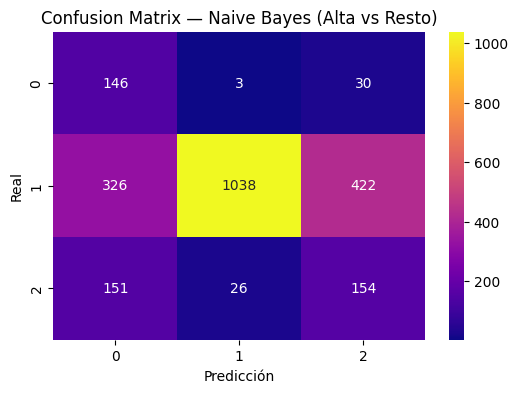

In [25]:
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="plasma")
plt.title("Confusion Matrix — Naive Bayes (Alta vs Resto)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


In [26]:
print("Accuracy:", accuracy_score(y_test, final_preds))
print("Train Accuracy:", gnb.score(X_train_nb_fs, y_train))
print("Test Accuracy :", gnb.score(X_test_nb_fs, y_test))


Accuracy: 0.5827526132404182
Train Accuracy: 0.5844947735191638
Test Accuracy : 0.5827526132404182


In [27]:
#NB con feature selection
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred_nb,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
Alta,0.234,0.816,0.364,179.000
Baja,0.973,0.581,0.728,1786.000
Media,0.254,0.465,0.329,331.000
accuracy,0.583,0.583,0.583,0.583
macro avg,0.487,0.621,0.473,2296.000
weighted avg,0.812,0.583,0.642,2296.000


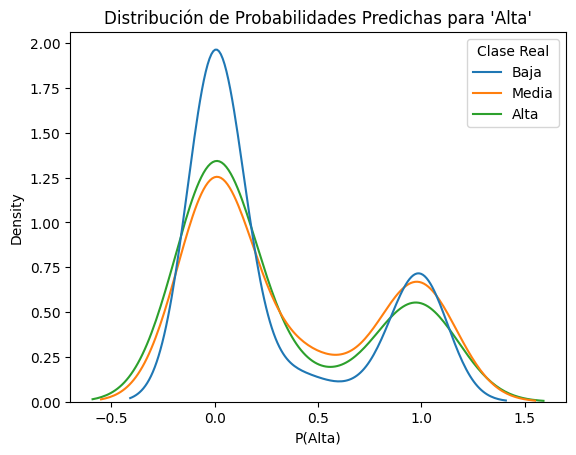

In [28]:
import pandas as pd
import seaborn as sns

# Obtener probabilidades para cada clase
probs = grid_nb.best_estimator_.predict_proba(X_test_nb_fs)
prob_df = pd.DataFrame(probs, columns=["P(Alta)", "P(Baja)", "P(Media)"])
prob_df["Clase Real"] = y_test

# Graficar distribución de probabilidades para "Alta"
sns.kdeplot(data=prob_df, x="P(Alta)", hue="Clase Real", common_norm=False)
plt.title("Distribución de Probabilidades Predichas para 'Alta'")
plt.show()


Importancia de Características (si usas SelectKBest)

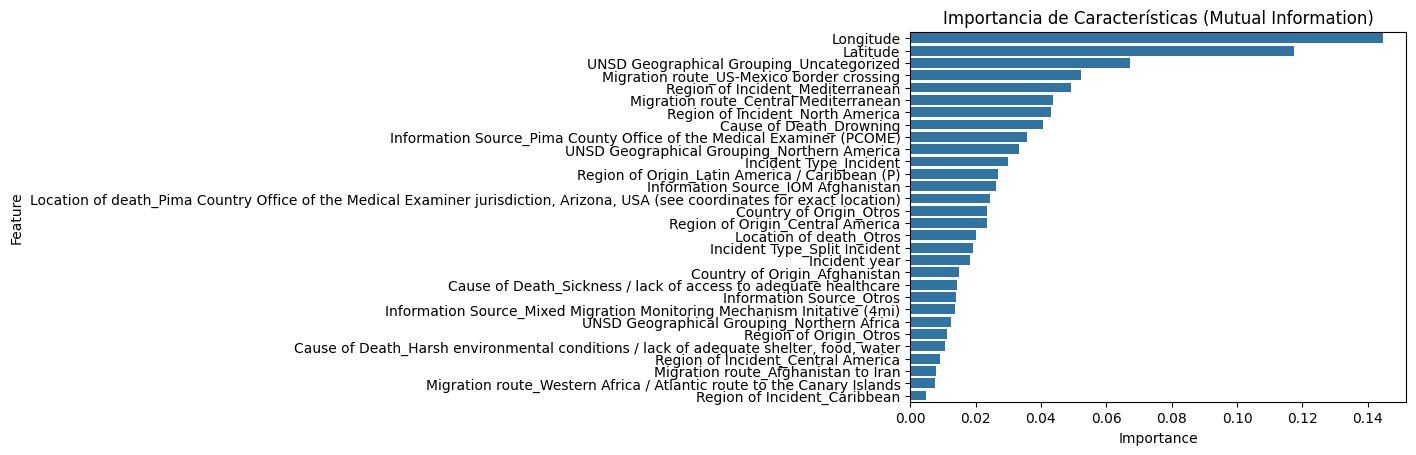

In [29]:
importances = mutual_info_classif(X_train_nb_fs, y_train)
feature_importance = pd.DataFrame({"Feature": X_train_nb_fs.columns, "Importance": importances})
feature_importance = feature_importance.sort_values("Importance", ascending=False)

sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Importancia de Características (Mutual Information)")
plt.show()


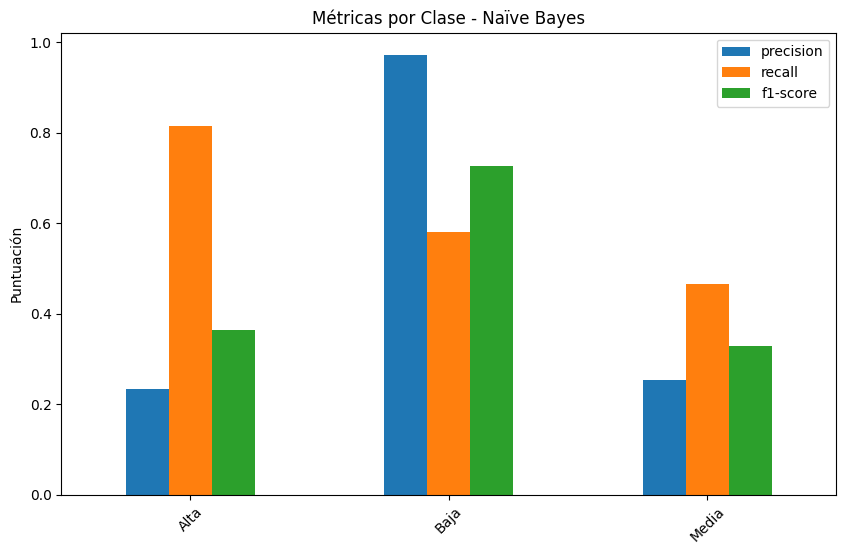

In [30]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred_nb, output_dict=True)
metrics_df = pd.DataFrame(report).transpose()

# Graficar métricas para cada clase
metrics_df[["precision", "recall", "f1-score"]].iloc[:-3].plot(kind="bar", figsize=(10, 6))
plt.title("Métricas por Clase - Naïve Bayes")
plt.ylabel("Puntuación")
plt.xticks(rotation=45)
plt.show()


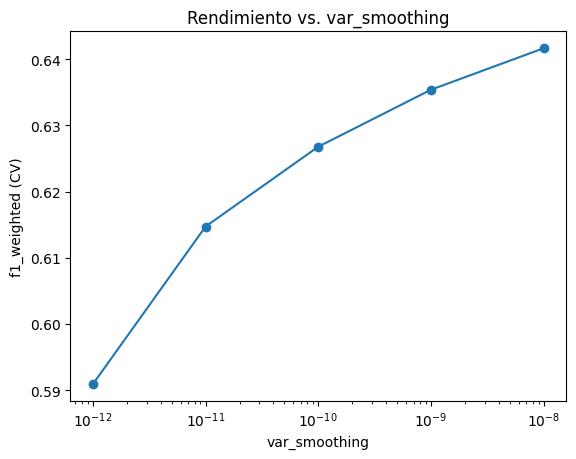

In [31]:
results = pd.DataFrame(grid_nb.cv_results_)
plt.plot(results["param_var_smoothing"], results["mean_test_score"], marker="o")
plt.xscale("log")
plt.title("Rendimiento vs. var_smoothing")
plt.xlabel("var_smoothing")
plt.ylabel("f1_weighted (CV)")
plt.show()


#PREPROCESSING PARA KNN Y SVM

In [32]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import RandomOverSampler



X_train_base = X_train_imp.copy()
X_test_base  = X_test_imp.copy()

num_cols = X_train_base.select_dtypes(include=["float64", "int64"]).columns.tolist()
cat_cols = X_train_base.select_dtypes(include="object").columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)


ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

ohe.fit(X_train_base[cat_cols])

X_train_ohe = pd.DataFrame(
    ohe.transform(X_train_base[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train_base.index
)

X_test_ohe = pd.DataFrame(
    ohe.transform(X_test_base[cat_cols]),
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test_base.index
)


scaler = StandardScaler()
scaler.fit(X_train_base[num_cols])

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train_base[num_cols]),
    columns=num_cols,
    index=X_train_base.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_base[num_cols]),
    columns=num_cols,
    index=X_test_base.index
)


X_train_linear = pd.concat([X_train_scaled, X_train_ohe], axis=1)
X_test_linear  = pd.concat([X_test_scaled,  X_test_ohe], axis=1)

print("Shape linear:", X_train_linear.shape, X_test_linear.shape)

k_features = 40   # 30–50 recomendado

fs = SelectKBest(
    score_func=f_classif,
    k=k_features
)

fs.fit(X_train_linear, y_train)

X_train_linear_fs = pd.DataFrame(
    fs.transform(X_train_linear),
    columns=X_train_linear.columns[fs.get_support()],
    index=X_train_linear.index
)

X_test_linear_fs = pd.DataFrame(
    fs.transform(X_test_linear),
    columns=X_train_linear_fs.columns,
    index=X_test_linear.index
)

print("Shape FS:", X_train_linear_fs.shape, X_test_linear_fs.shape)


ros = RandomOverSampler(random_state=42)

X_train_knn, y_train_knn = ros.fit_resample(
    X_train_linear_fs,
    y_train
)

print("Distribución KNN balanceada:")
print(y_train_knn.value_counts())

X_train_svm = X_train_linear_fs.copy()
y_train_svm = y_train.copy()


Numéricas: ['Incident year', 'Latitude', 'Longitude']
Categóricas: ['Incident Type', 'Reported Month', 'Region of Origin', 'Region of Incident', 'Country of Origin', 'Cause of Death', 'Migration route', 'Location of death', 'Information Source', 'UNSD Geographical Grouping']
Shape linear: (9184, 145) (2296, 145)
Shape FS: (9184, 40) (2296, 40)
Distribución KNN balanceada:
Severidad
Baja     7145
Media    7145
Alta     7145
Name: count, dtype: int64


# ENTRENO DE KNN

In [33]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV



kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_knn = {
    "n_neighbors": list(range(1, 31, 2)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean"]   # ya está escalado
}


grid_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid_knn,
    cv=kfold,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_knn.fit(X_train_knn, y_train_knn)

print("Mejores parámetros KNN:", grid_knn.best_params_)
print("Mejor F1 CV:", grid_knn.best_score_)


best_knn = grid_knn.best_estimator_

best_knn.fit(X_train_knn, y_train_knn)


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
import seaborn as sns

y_pred_knn = best_knn.predict(X_test_linear_fs)


print("\n=== INFORME KNN ===\n")
print(classification_report(y_test, y_pred_knn))


Mejores parámetros KNN: {'metric': 'euclidean', 'n_neighbors': 29, 'weights': 'distance'}
Mejor F1 CV: 0.9018870312081247

=== INFORME KNN ===

              precision    recall  f1-score   support

        Alta       0.37      0.59      0.46       179
        Baja       0.92      0.79      0.85      1786
       Media       0.31      0.46      0.37       331

    accuracy                           0.73      2296
   macro avg       0.54      0.61      0.56      2296
weighted avg       0.79      0.73      0.75      2296



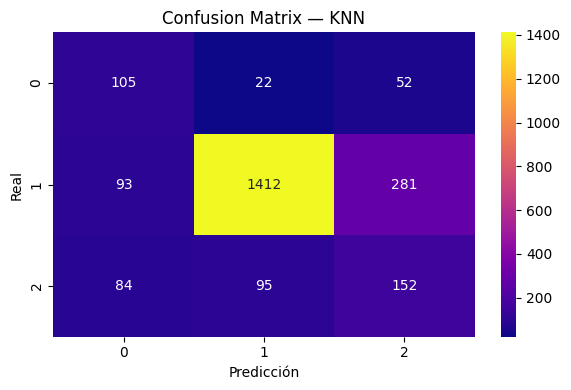

In [34]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="plasma")
plt.title("Confusion Matrix — KNN")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


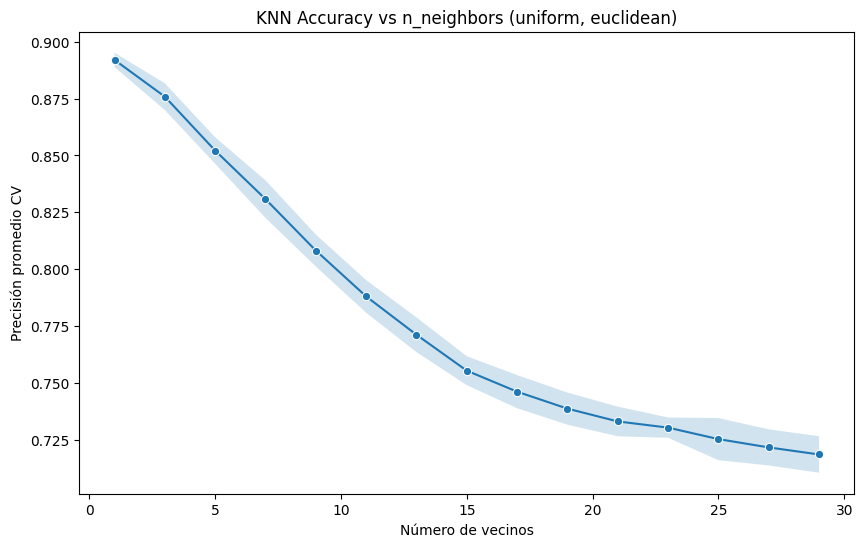

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

results_knn = pd.DataFrame(grid_knn.cv_results_)

# Filtramos una combinación simple para visualizar
subset = results_knn[(results_knn['param_weights'] == 'uniform') &
                     (results_knn['param_metric'] == 'euclidean')]

plt.figure(figsize=(10,6))
sns.lineplot(x='param_n_neighbors', y='mean_test_score', data=subset, marker='o')
plt.fill_between(subset['param_n_neighbors'],
                 subset['mean_test_score'] - subset['std_test_score'],
                 subset['mean_test_score'] + subset['std_test_score'],
                 alpha=0.2)
plt.title("KNN Accuracy vs n_neighbors (uniform, euclidean)")
plt.xlabel("Número de vecinos")
plt.ylabel("Precisión promedio CV")
plt.show()


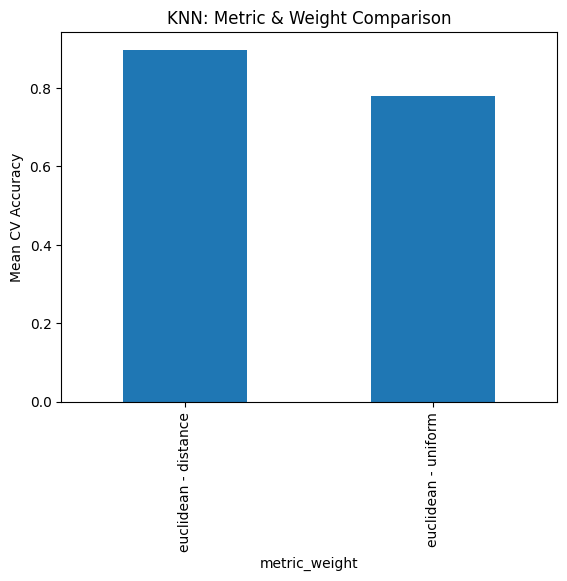

In [36]:
results = pd.DataFrame(grid_knn.cv_results_)

results['metric_weight'] = (
    results['param_metric'].astype(str) + " - " +
    results['param_weights'].astype(str)
)

mean_scores = results.groupby('metric_weight')['mean_test_score'].mean()

plt.figure()
mean_scores.plot(kind='bar')
plt.ylabel("Mean CV Accuracy")
plt.title("KNN: Metric & Weight Comparison")
plt.show()


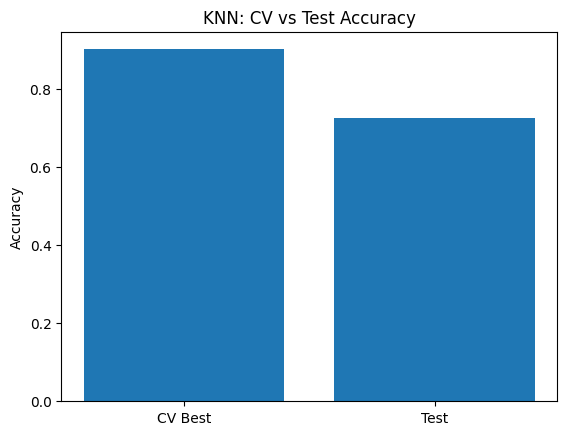

In [37]:
from sklearn.metrics import accuracy_score

test_acc = accuracy_score(y_test, y_pred_knn)

plt.figure()
plt.bar(['CV Best', 'Test'],
        [grid_knn.best_score_, test_acc])
plt.ylabel("Accuracy")
plt.title("KNN: CV vs Test Accuracy")
plt.show()


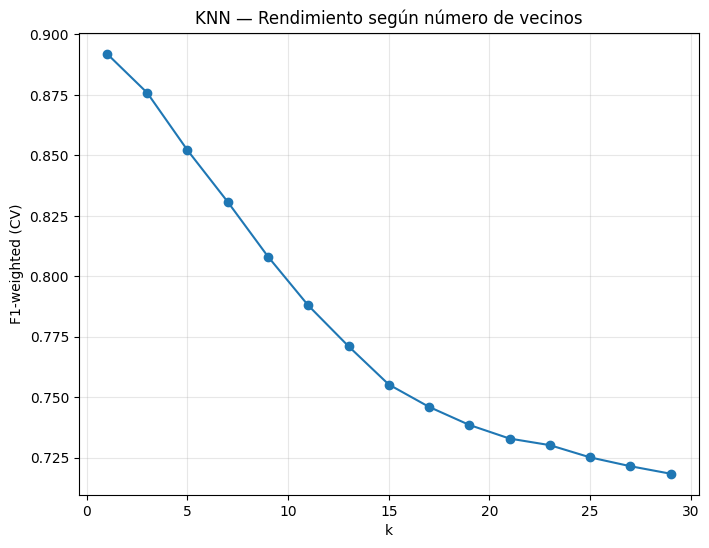

In [102]:
import pandas as pd

results_knn = pd.DataFrame(grid_knn.cv_results_)

subset = results_knn[
    (results_knn["param_weights"]=="uniform")
]

plt.figure(figsize=(8,6))
plt.plot(subset["param_n_neighbors"], subset["mean_test_score"], marker="o")
plt.xlabel("k")
plt.ylabel("F1-weighted (CV)")
plt.title("KNN — Rendimiento según número de vecinos")
plt.grid(alpha=0.3)
plt.show()



#ENTRENO SVM

SVM linear

Mejor C: {'C': np.float64(0.1)}
Mejor F1 CV: 0.7575488737951438

=== SVM LINEAR ===

              precision    recall  f1-score   support

        Alta       0.34      0.73      0.46       179
        Baja       0.91      0.81      0.85      1786
       Media       0.36      0.34      0.35       331

    accuracy                           0.74      2296
   macro avg       0.54      0.63      0.56      2296
weighted avg       0.78      0.74      0.75      2296



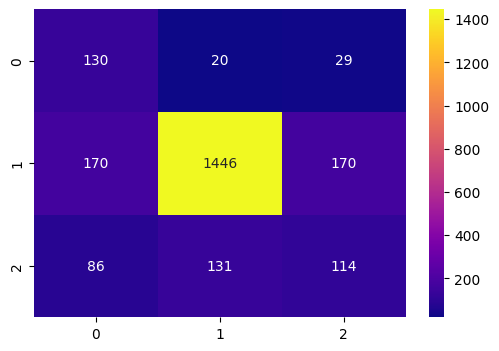

Accuracy: 0.7360627177700348
Norma del vector de pesos: 4.167768909036933


In [45]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid_linear = {
    "C": np.logspace(-3, 3, 7)
}

grid_linear = GridSearchCV(
    LinearSVC(
        class_weight="balanced",  # IMPORTANTE
        dual=False,               # MÁS RÁPIDO CUANDO n_samples > n_features
        max_iter=5000
    ),
    param_grid_linear,
    cv=kfold,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_linear.fit(X_train_svm, y_train_svm)

print("Mejor C:", grid_linear.best_params_)
print("Mejor F1 CV:", grid_linear.best_score_)



scores = grid_linear.cv_results_["mean_test_score"]

svm_linear = grid_linear.best_estimator_
pred_linear = svm_linear.predict(X_test_linear_fs)

print("\n=== SVM LINEAR ===\n")
print(classification_report(y_test, pred_linear))

cm = confusion_matrix(y_test, pred_linear)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="plasma")
plt.show()

print("Accuracy:", accuracy_score(y_test, pred_linear))
w_norm = np.linalg.norm(svm_linear.coef_)
print("Norma del vector de pesos:", w_norm)


SVM poly

Mejores params poly: {'C': 10, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}
Mejor F1 CV: 0.7600641313012645

=== SVM POLY ===

              precision    recall  f1-score   support

        Alta       0.56      0.48      0.52       179
        Baja       0.84      0.95      0.90      1786
       Media       0.46      0.18      0.25       331

    accuracy                           0.80      2296
   macro avg       0.62      0.54      0.56      2296
weighted avg       0.77      0.80      0.77      2296



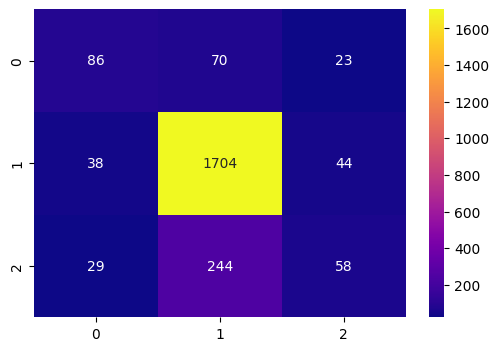

In [48]:
param_grid_poly = {
    "C": [0.1, 1, 10],
    "degree": [2, 3],
    "gamma": ["scale"],
    "kernel": ["poly"]
}

grid_poly = GridSearchCV(
    SVC(),
    param_grid_poly,
    cv=3,                    # REDUCIDO
    scoring="f1_weighted",
    n_jobs=-1
)

grid_poly.fit(X_train_svm, y_train_svm)

print("Mejores params poly:", grid_poly.best_params_)
print("Mejor F1 CV:", grid_poly.best_score_)


scores_poly = grid_poly.cv_results_["mean_test_score"]
scores_poly = np.array(scores_poly).reshape(
    len(param_grid_poly["C"]),
    len(param_grid_poly["degree"])
)


svm_poly = grid_poly.best_estimator_
pred_poly = svm_poly.predict(X_test_linear_fs)

print("\n=== SVM POLY ===\n")
print(classification_report(y_test, pred_poly))

cm = confusion_matrix(y_test, pred_poly)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="plasma")
plt.show()



SVM rbf

Mejores params RBF: {'C': 100, 'gamma': 1, 'kernel': 'rbf'}
Mejor F1 CV: 0.7630989595396779

=== SVM RBF ===

              precision    recall  f1-score   support

        Alta       0.56      0.49      0.52       179
        Baja       0.85      0.95      0.90      1786
       Media       0.48      0.23      0.31       331

    accuracy                           0.81      2296
   macro avg       0.63      0.56      0.58      2296
weighted avg       0.78      0.81      0.78      2296



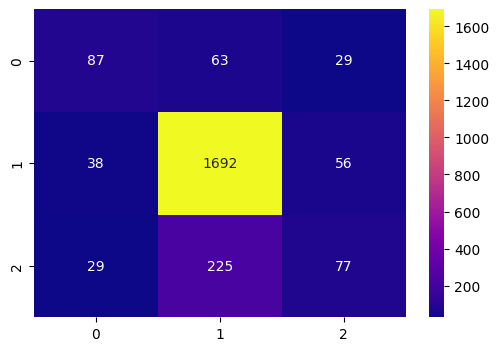

In [51]:
param_grid_rbf = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.01, 0.1, 1],
    "kernel": ["rbf"]
}

grid_rbf = GridSearchCV(
    SVC(),
    param_grid_rbf,
    cv=3,                      # REDUCIDO
    scoring="f1_weighted",
    n_jobs=-1
)

grid_rbf.fit(X_train_svm, y_train_svm)

print("Mejores params RBF:", grid_rbf.best_params_)
print("Mejor F1 CV:", grid_rbf.best_score_)



scores_rbf = grid_rbf.cv_results_["mean_test_score"]
scores_rbf = np.array(scores_rbf).reshape(
    len(param_grid_rbf["C"]),
    len(param_grid_rbf["gamma"])
)


svm_rbf = grid_rbf.best_estimator_
pred_rbf = svm_rbf.predict(X_test_linear_fs)

print("\n=== SVM RBF ===\n")
print(classification_report(y_test, pred_rbf))

cm = confusion_matrix(y_test, pred_rbf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="plasma")
plt.show()


In [52]:
best_svm = max(
    [grid_linear, grid_poly, grid_rbf],
    key=lambda g: g.best_score_
)

print("MEJOR MODELO SVM:", best_svm.best_estimator_)
print("MEJOR F1 CV:", best_svm.best_score_)

final_preds = best_svm.best_estimator_.predict(X_test_linear_fs)

print("\n=== INFORME FINAL SVM ===\n")
print(classification_report(y_test, final_preds))


MEJOR MODELO SVM: SVC(C=100, gamma=1)
MEJOR F1 CV: 0.7630989595396779

=== INFORME FINAL SVM ===

              precision    recall  f1-score   support

        Alta       0.56      0.49      0.52       179
        Baja       0.85      0.95      0.90      1786
       Media       0.48      0.23      0.31       331

    accuracy                           0.81      2296
   macro avg       0.63      0.56      0.58      2296
weighted avg       0.78      0.81      0.78      2296



PREPROCESSING PARA ARBOLES

In [53]:
# =========================a
# RAMA ÁRBOLES
# =========================

ohe_tree = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe_tree.fit(X_train_base[cat_cols])

X_train_tree = pd.DataFrame(
    ohe_tree.transform(X_train_base[cat_cols]),
    columns=ohe_tree.get_feature_names_out(cat_cols),
    index=X_train_base.index
)

X_test_tree = pd.DataFrame(
    ohe_tree.transform(X_test_base[cat_cols]),
    columns=ohe_tree.get_feature_names_out(cat_cols),
    index=X_test_base.index
)

# Añadir numéricas SIN ESCALAR
X_train_tree = pd.concat(
    [X_train_base[num_cols], X_train_tree],
    axis=1
)

X_test_tree = pd.concat(
    [X_test_base[num_cols], X_test_tree],
    axis=1
)

print("Tree:", X_train_tree.shape, X_test_tree.shape)


Tree: (9184, 145) (2296, 145)


DECISION TREES

Mejores parámetros DT: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Mejor F1 CV: 0.758274397333746

=== INFORME DECISION TREE ===

              precision    recall  f1-score   support

        Alta       0.40      0.39      0.39       179
        Baja       0.88      0.88      0.88      1786
       Media       0.35      0.35      0.35       331

    accuracy                           0.77      2296
   macro avg       0.54      0.54      0.54      2296
weighted avg       0.77      0.77      0.77      2296



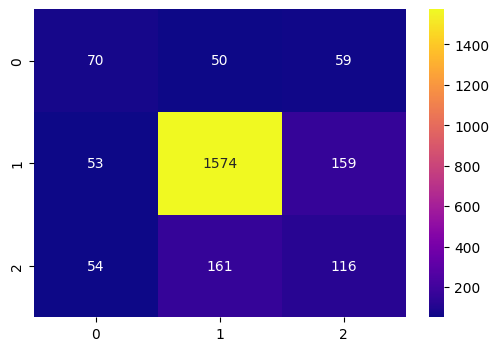

Accuracy: 0.7665505226480837


In [54]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10]
}

dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

grid_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_dt.fit(X_train_tree, y_train)

print("Mejores parámetros DT:", grid_dt.best_params_)
print("Mejor F1 CV:", grid_dt.best_score_)


best_tree = grid_dt.best_estimator_

best_tree.fit(X_train_tree, y_train)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
import seaborn as sns

pred_dt = best_tree.predict(X_test_tree)

print("\n=== INFORME DECISION TREE ===\n")
print(classification_report(y_test, pred_dt))

cm = confusion_matrix(y_test, pred_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="plasma")
plt.show()

print("Accuracy:", accuracy_score(y_test, pred_dt))


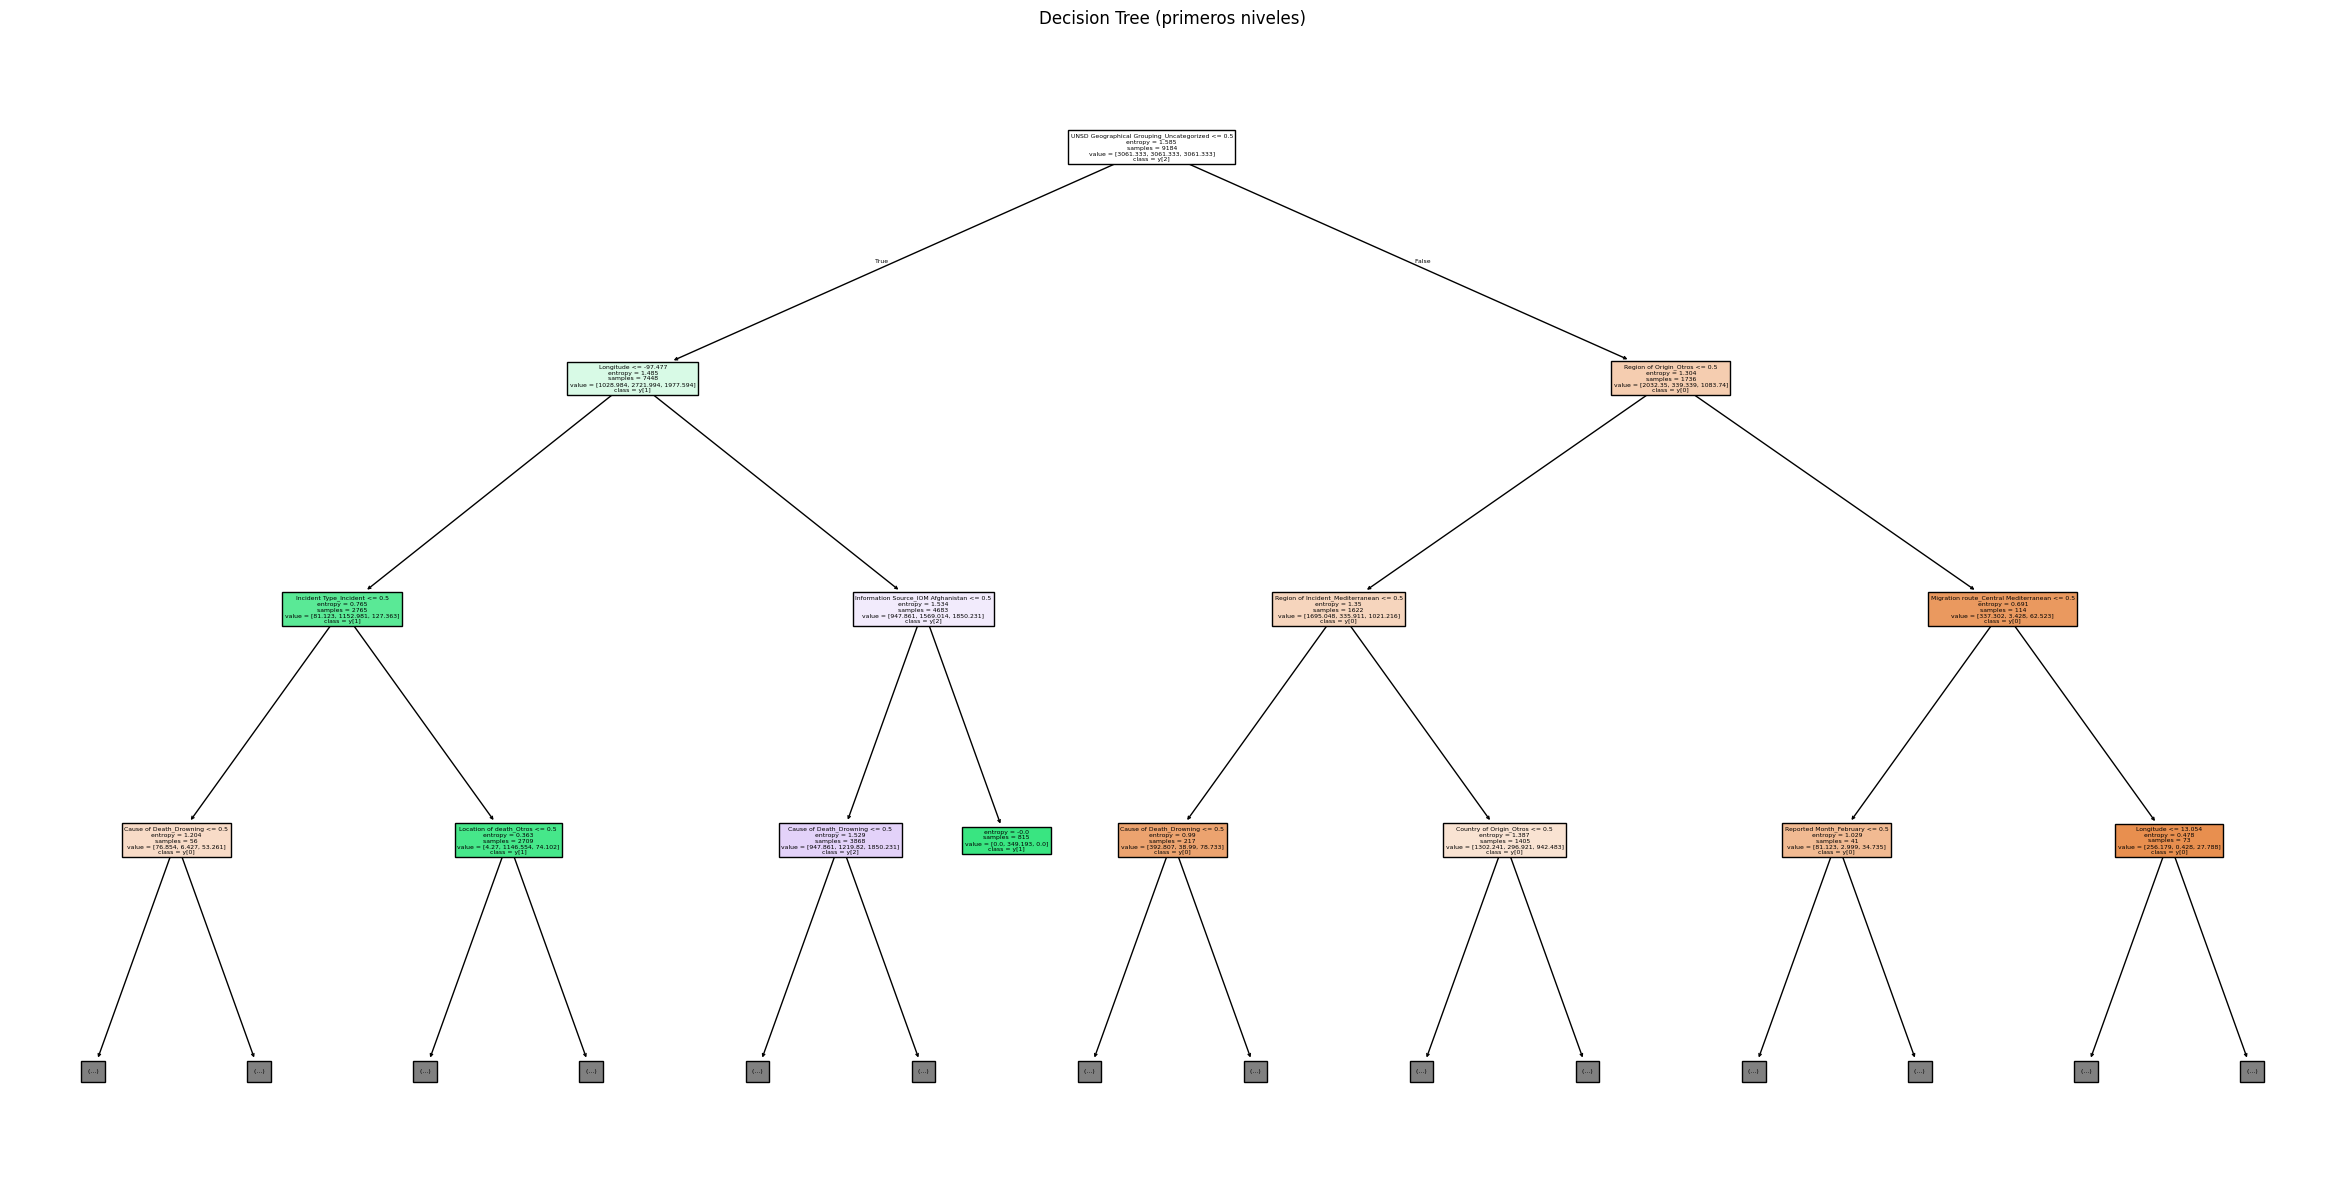

In [56]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(30, 15))
tree.plot_tree(
    best_tree,
    max_depth=3,
    filled=True,
    feature_names=X_train_tree.columns,
    class_names=True
)
plt.title("Decision Tree (primeros niveles)")
plt.show()


# META LEARNING ALGORITHIMS

Bagging

In [58]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lb = []
best_acc = 0
best_n = 0

for n_estimators in [5, 10, 20, 50]:
    bagging = BaggingClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=None,
            random_state=42
        ),
        n_estimators=n_estimators,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        bagging,
        X_train_tree,
        y_train,
        cv=cv,
        scoring="f1_weighted"
    )

    mean_score = scores.mean()
    lb.append(mean_score)

    if mean_score > best_acc:
        best_acc = mean_score
        best_n = n_estimators

    print(f"F1_weighted: {mean_score:.4f} | n_estimators={n_estimators}")

print(f"\nMejor número de estimadores: {best_n} (F1={best_acc:.4f})")


F1_weighted: 0.7750 | n_estimators=5
F1_weighted: 0.7809 | n_estimators=10
F1_weighted: 0.7843 | n_estimators=20
F1_weighted: 0.7890 | n_estimators=50

Mejor número de estimadores: 50 (F1=0.7890)


In [59]:
lb2 = []
best_acc = 0
best_n_feat = 0

max_features = 0.5

for n_estimators in [5, 10, 20, 50]:
    bagging = BaggingClassifier(
        estimator=DecisionTreeClassifier(
            random_state=42
        ),
        n_estimators=n_estimators,
        max_features=max_features,
        random_state=42,
        n_jobs=-1
    )

    scores = cross_val_score(
        bagging,
        X_train_tree,
        y_train,
        cv=cv,
        scoring="f1_weighted"
    )

    mean_score = scores.mean()
    lb2.append(mean_score)

    if mean_score > best_acc:
        best_acc = mean_score
        best_n_feat = n_estimators

    print(f"F1_weighted: {mean_score:.4f} | n_estimators={n_estimators}")

print(f"\nMejor n_estimators={best_n_feat} con max_features={max_features} (F1={best_acc:.4f})")


F1_weighted: 0.7675 | n_estimators=5
F1_weighted: 0.7726 | n_estimators=10
F1_weighted: 0.7776 | n_estimators=20
F1_weighted: 0.7850 | n_estimators=50

Mejor n_estimators=50 con max_features=0.5 (F1=0.7850)



=== INFORME BAGGING DECISION TREE ===

              precision    recall  f1-score   support

        Alta       0.63      0.44      0.52       179
        Baja       0.86      0.95      0.90      1786
       Media       0.41      0.23      0.29       331

    accuracy                           0.81      2296
   macro avg       0.63      0.54      0.57      2296
weighted avg       0.77      0.81      0.78      2296



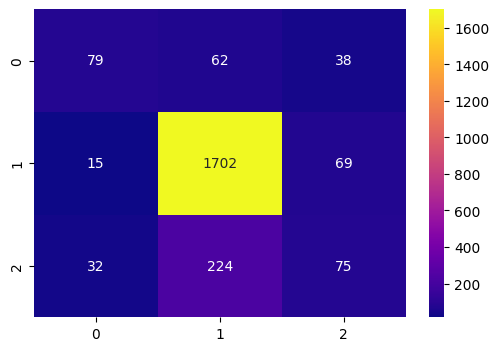

Accuracy: 0.8083623693379791


In [66]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

pred_bag = bagging_final.predict(X_test_tree)

print("\n=== INFORME BAGGING DECISION TREE ===\n")
print(classification_report(y_test, pred_bag))

cm = confusion_matrix(y_test, pred_bag)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="plasma")
plt.show()

print("Accuracy:", accuracy_score(y_test, pred_bag))


Random Forest

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("RESULTADOS RANDOM FOREST:\n")

rf_scores = []
best_f1 = 0
best_n = 0

for n_estimators in [10, 20, 50, 100]:
    rf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

    scores = cross_val_score(
        rf,
        X_train_tree,
        y_train,
        cv=cv,
        scoring="f1_weighted"
    )

    mean_f1 = scores.mean()
    rf_scores.append(mean_f1)

    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_n = n_estimators

    print(f"F1_weighted: {mean_f1:.4f} | n_estimators={n_estimators}")

print(f"\nMejor número de árboles: {best_n} (F1={best_f1:.4f})")


RESULTADOS RANDOM FOREST:

F1_weighted: 0.7797 | n_estimators=10
F1_weighted: 0.7833 | n_estimators=20
F1_weighted: 0.7857 | n_estimators=50
F1_weighted: 0.7885 | n_estimators=100

Mejor número de árboles: 100 (F1=0.7885)


In [69]:
rf_final = RandomForestClassifier(
    n_estimators=best_n,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_final.fit(X_train_tree, y_train)


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)


=== INFORME RANDOM FOREST ===

              precision    recall  f1-score   support

        Alta       0.55      0.43      0.48       179
        Baja       0.87      0.94      0.90      1786
       Media       0.44      0.31      0.36       331

    accuracy                           0.81      2296
   macro avg       0.62      0.56      0.58      2296
weighted avg       0.78      0.81      0.79      2296



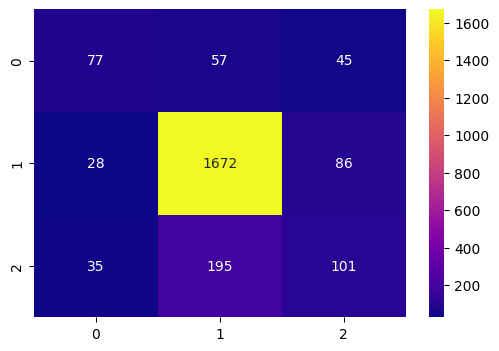

Accuracy: 0.8057491289198606


In [70]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

pred_rf = rf_final.predict(X_test_tree)

print("\n=== INFORME RANDOM FOREST ===\n")
print(classification_report(y_test, pred_rf))

cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="plasma")
plt.show()

print("Accuracy:", accuracy_score(y_test, pred_rf))


EXTRA TREES

In [72]:
from sklearn.ensemble import ExtraTreesClassifier

print("RESULTADOS EXTRA TREES:\n")

et_scores = []
best_f1 = 0
best_n = 0

for n_estimators in [10, 20, 50, 100]:
    et = ExtraTreesClassifier(
        n_estimators=n_estimators,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )

    scores = cross_val_score(
        et,
        X_train_tree,
        y_train,
        cv=cv,
        scoring="f1_weighted"
    )

    mean_f1 = scores.mean()
    et_scores.append(mean_f1)

    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_n = n_estimators

    print(f"F1_weighted: {mean_f1:.4f} | n_estimators={n_estimators}")

print(f"\nMejor número de árboles: {best_n} (F1={best_f1:.4f})")


RESULTADOS EXTRA TREES:

F1_weighted: 0.7818 | n_estimators=10
F1_weighted: 0.7843 | n_estimators=20
F1_weighted: 0.7855 | n_estimators=50
F1_weighted: 0.7849 | n_estimators=100

Mejor número de árboles: 50 (F1=0.7855)


In [73]:
et_final = ExtraTreesClassifier(
    n_estimators=best_n,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

et_final.fit(X_train_tree, y_train)


ExtraTreesClassifier(class_weight='balanced', n_estimators=50, n_jobs=-1,
                     random_state=42)


=== INFORME EXTRA TREES ===

              precision    recall  f1-score   support

        Alta       0.48      0.41      0.44       179
        Baja       0.88      0.92      0.90      1786
       Media       0.40      0.33      0.36       331

    accuracy                           0.79      2296
   macro avg       0.58      0.55      0.57      2296
weighted avg       0.78      0.79      0.78      2296



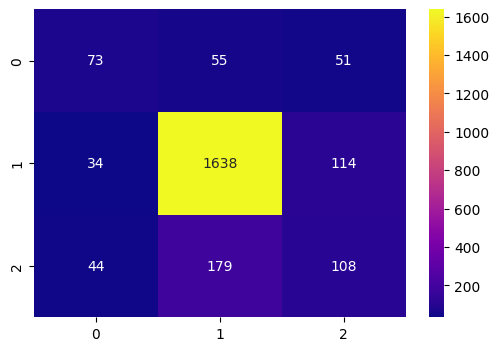

Accuracy: 0.7922473867595818


In [75]:
pred_et = et_final.predict(X_test_tree)

print("\n=== INFORME EXTRA TREES ===\n")
print(classification_report(y_test, pred_et))

cm = confusion_matrix(y_test, pred_et)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="plasma")
plt.show()

print("Accuracy:", accuracy_score(y_test, pred_et))


AdaBoost

In [77]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("RESULTADOS ADABOOST (stumps):\n")

ada_scores = []
best_f1 = 0
best_n = 0

for n_estimators in [10, 20, 50, 100]:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=42
        ),
        n_estimators=n_estimators,
        learning_rate=1.0,
        random_state=42
    )

    scores = cross_val_score(
        ada,
        X_train_tree,
        y_train,
        cv=cv,
        scoring="f1_weighted"
    )

    mean_f1 = scores.mean()
    ada_scores.append(mean_f1)

    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_n = n_estimators

    print(f"F1_weighted: {mean_f1:.4f} | n_estimators={n_estimators}")

print(f"\nMejor número de estimadores: {best_n} (F1={best_f1:.4f})")


RESULTADOS ADABOOST (stumps):

F1_weighted: 0.6968 | n_estimators=10
F1_weighted: 0.7055 | n_estimators=20
F1_weighted: 0.7265 | n_estimators=50
F1_weighted: 0.7323 | n_estimators=100

Mejor número de estimadores: 100 (F1=0.7323)


In [78]:
print("\nRESULTADOS ADABOOST (depth=3):\n")

best_f1 = 0
best_n_depth = 0
max_depth = 3

for n_estimators in [10, 20, 50, 100]:
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=max_depth,
            random_state=42
        ),
        n_estimators=n_estimators,
        learning_rate=1.0,
        random_state=42
    )

    scores = cross_val_score(
        ada,
        X_train_tree,
        y_train,
        cv=cv,
        scoring="f1_weighted"
    )

    mean_f1 = scores.mean()

    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_n_depth = n_estimators

    print(f"F1_weighted: {mean_f1:.4f} | n_estimators={n_estimators}")

print(f"\nMejor n_estimators={best_n_depth} con max_depth={max_depth} (F1={best_f1:.4f})")



RESULTADOS ADABOOST (depth=3):

F1_weighted: 0.7466 | n_estimators=10
F1_weighted: 0.7510 | n_estimators=20
F1_weighted: 0.7561 | n_estimators=50
F1_weighted: 0.7649 | n_estimators=100

Mejor n_estimators=100 con max_depth=3 (F1=0.7649)


In [80]:
ada_final = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ),
    n_estimators=best_n_depth,
    learning_rate=1.0,
    random_state=42
)

ada_final.fit(X_train_tree, y_train)


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=42),
                   n_estimators=100, random_state=42)


=== INFORME ADABOOST ===

              precision    recall  f1-score   support

        Alta       0.60      0.45      0.52       179
        Baja       0.84      0.96      0.90      1786
       Media       0.38      0.12      0.19       331

    accuracy                           0.80      2296
   macro avg       0.61      0.51      0.53      2296
weighted avg       0.75      0.80      0.76      2296



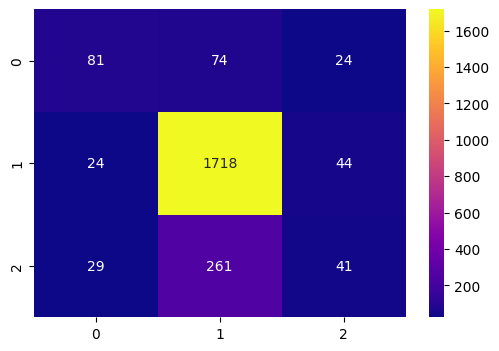

Accuracy: 0.8013937282229965


In [81]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

pred_ada = ada_final.predict(X_test_tree)

print("\n=== INFORME ADABOOST ===\n")
print(classification_report(y_test, pred_ada))

cm = confusion_matrix(y_test, pred_ada)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="plasma")
plt.show()

print("Accuracy:", accuracy_score(y_test, pred_ada))


# Resultados

In [83]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

preds = {
    "Naive Bayes": y_pred_nb,
    "KNN": y_pred_knn,
    "Decision Tree": pred_dt,
    "SVM": final_preds,      # tu mejor SVM
    "Random Forest": pred_rf,
    "Extra Trees": pred_et,
    "AdaBoost": pred_ada
}

summary = []

for model, y_pred in preds.items():
    summary.append({
        "Modelo": model,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted")
    })

df_summary = pd.DataFrame(summary).sort_values("F1_weighted", ascending=False)
df_summary


,Modelo,Accuracy,F1_weighted
4,Random Forest,0.806,0.790
3,SVM,0.808,0.785
5,Extra Trees,0.792,0.783
2,Decision Tree,0.767,0.767
6,AdaBoost,0.801,0.763
1,KNN,0.727,0.752
0,Naive Bayes,0.583,0.642


In [84]:
best_model_name = df_summary.iloc[0]["Modelo"]
best_model_name


'Random Forest'

McNemar Test

In [85]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

def mcnemar_test(y_true, y_pred_1, y_pred_2, model1, model2):
    correct_1 = (y_pred_1 == y_true)
    correct_2 = (y_pred_2 == y_true)

    table = np.zeros((2, 2), dtype=int)

    table[0, 0] = np.sum((correct_1) & (correct_2))
    table[0, 1] = np.sum((correct_1) & (~correct_2))
    table[1, 0] = np.sum((~correct_1) & (correct_2))
    table[1, 1] = np.sum((~correct_1) & (~correct_2))

    result = mcnemar(table, exact=True)

    print(f"\nMcNemar: {model1} vs {model2}")
    print("Tabla:")
    print(table)
    print(f"Statistic={result.statistic}, p-value={result.pvalue:.5f}")

    if result.pvalue < 0.05:
        print("➡️ Diferencia estadísticamente significativa")
    else:
        print("➡️ NO hay diferencia significativa")


In [86]:
best_preds = preds[best_model_name]

for model, y_pred in preds.items():
    if model != best_model_name:
        mcnemar_test(
            y_test,
            best_preds,
            y_pred,
            best_model_name,
            model
        )



McNemar: Random Forest vs Naive Bayes
Tabla:
[[1155  695]
 [ 183  263]]
Statistic=183.0, p-value=0.00000
➡️ Diferencia estadísticamente significativa

McNemar: Random Forest vs KNN
Tabla:
[[1533  317]
 [ 136  310]]
Statistic=136.0, p-value=0.00000
➡️ Diferencia estadísticamente significativa

McNemar: Random Forest vs Decision Tree
Tabla:
[[1671  179]
 [  89  357]]
Statistic=89.0, p-value=0.00000
➡️ Diferencia estadísticamente significativa

McNemar: Random Forest vs SVM
Tabla:
[[1732  118]
 [ 124  322]]
Statistic=118.0, p-value=0.74797
➡️ NO hay diferencia significativa

McNemar: Random Forest vs Extra Trees
Tabla:
[[1785   65]
 [  34  412]]
Statistic=34.0, p-value=0.00239
➡️ Diferencia estadísticamente significativa

McNemar: Random Forest vs AdaBoost
Tabla:
[[1720  130]
 [ 120  326]]
Statistic=120.0, p-value=0.56930
➡️ NO hay diferencia significativa


Intervalos de confianza

In [87]:
from statsmodels.stats.proportion import proportion_confint

def accuracy_ci(y_true, y_pred, alpha=0.05):
    acc = accuracy_score(y_true, y_pred)
    n = len(y_true)
    low, high = proportion_confint(
        count=int(acc * n),
        nobs=n,
        alpha=alpha,
        method="wilson"
    )
    return acc, low, high


In [88]:
ci_results = []

for model, y_pred in preds.items():
    acc, low, high = accuracy_ci(y_test, y_pred)
    ci_results.append({
        "Modelo": model,
        "Accuracy": acc,
        "IC_95_inf": low,
        "IC_95_sup": high
    })

df_ci = pd.DataFrame(ci_results).sort_values("Accuracy", ascending=False)
df_ci


,Modelo,Accuracy,IC_95_inf,IC_95_sup
3,SVM,0.808,0.792,0.824
4,Random Forest,0.806,0.789,0.821
6,AdaBoost,0.801,0.785,0.817
5,Extra Trees,0.792,0.775,0.808
2,Decision Tree,0.767,0.749,0.783
1,KNN,0.727,0.708,0.745
0,Naive Bayes,0.583,0.562,0.603


In [89]:
from sklearn.utils import resample
import numpy as np

def bootstrap_f1_ci(y_true, y_pred, n_bootstrap=1000, alpha=0.05):
    scores = []

    for _ in range(n_bootstrap):
        idx = resample(range(len(y_true)))
        score = f1_score(
            y_true[idx],
            y_pred[idx],
            average="weighted"
        )
        scores.append(score)

    lower = np.percentile(scores, 100 * alpha / 2)
    upper = np.percentile(scores, 100 * (1 - alpha / 2))

    return np.mean(scores), lower, upper


In [90]:
for model, y_pred in preds.items():
    mean_f1, low, high = bootstrap_f1_ci(y_test.values, y_pred)
    print(f"{model}: F1={mean_f1:.4f} [{low:.4f}, {high:.4f}]")


Naive Bayes: F1=0.6426 [0.6248, 0.6616]
KNN: F1=0.7520 [0.7358, 0.7688]
Decision Tree: F1=0.7667 [0.7485, 0.7836]
SVM: F1=0.7848 [0.7655, 0.8039]
Random Forest: F1=0.7900 [0.7712, 0.8085]
Extra Trees: F1=0.7827 [0.7657, 0.8013]
AdaBoost: F1=0.7632 [0.7424, 0.7839]


In [95]:
import pandas as pd

results = pd.DataFrame({
    "Modelo": [
        "Naive Bayes", "KNN", "Decision Tree",
        "SVM", "Random Forest", "Extra Trees", "AdaBoost"
    ],
    "Accuracy": [0.583, 0.727, 0.767, 0.808, 0.806, 0.792, 0.801],
    "F1": [0.6426, 0.7520, 0.7667, 0.7848, 0.7900, 0.7827, 0.7632],
    "F1_low": [0.6248, 0.7358, 0.7485, 0.7655, 0.7712, 0.7657, 0.7424],
    "F1_high": [0.6616, 0.7688, 0.7836, 0.8039, 0.8085, 0.8013, 0.7839]
})

results = results.sort_values("F1", ascending=False)
results


,Modelo,Accuracy,F1,F1_low,F1_high
4,Random Forest,0.806,0.790,0.771,0.808
3,SVM,0.808,0.785,0.765,0.804
5,Extra Trees,0.792,0.783,0.766,0.801
2,Decision Tree,0.767,0.767,0.749,0.784
6,AdaBoost,0.801,0.763,0.742,0.784
1,KNN,0.727,0.752,0.736,0.769
0,Naive Bayes,0.583,0.643,0.625,0.662


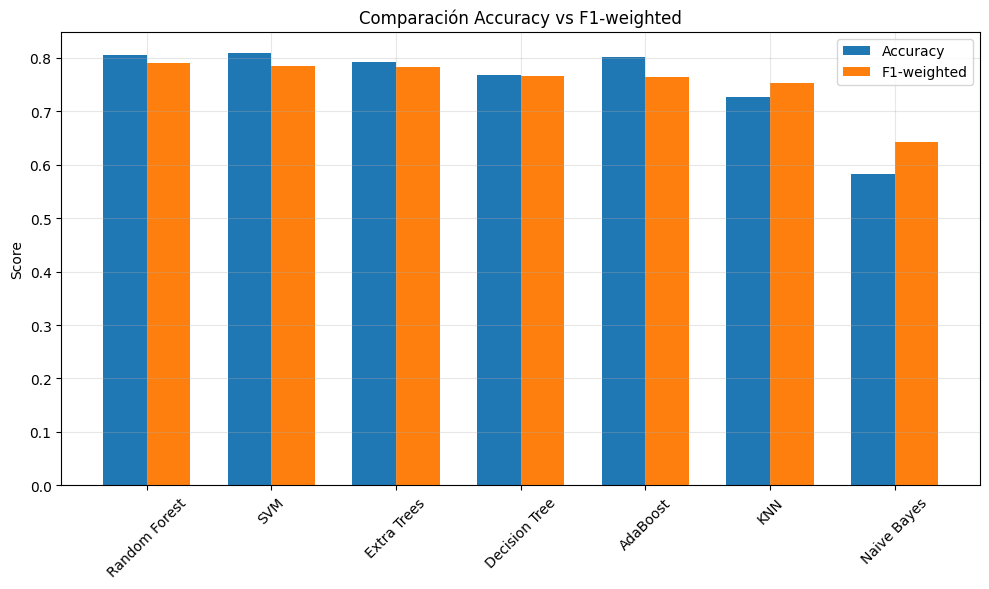

In [92]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(results))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, results["Accuracy"], width, label="Accuracy")
plt.bar(x + width/2, results["F1"], width, label="F1-weighted")

plt.xticks(x, results["Modelo"], rotation=45)
plt.ylabel("Score")
plt.title("Comparación Accuracy vs F1-weighted")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


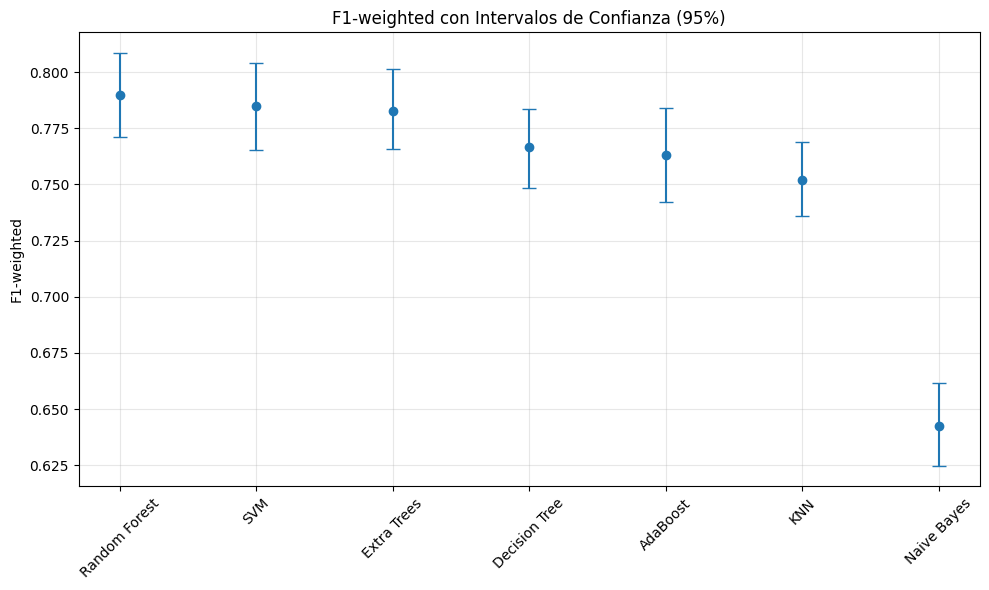

In [93]:
plt.figure(figsize=(10,6))

plt.errorbar(
    results["Modelo"],
    results["F1"],
    yerr=[
        results["F1"] - results["F1_low"],
        results["F1_high"] - results["F1"]
    ],
    fmt="o",
    capsize=5
)

plt.ylabel("F1-weighted")
plt.title("F1-weighted con Intervalos de Confianza (95%)")
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


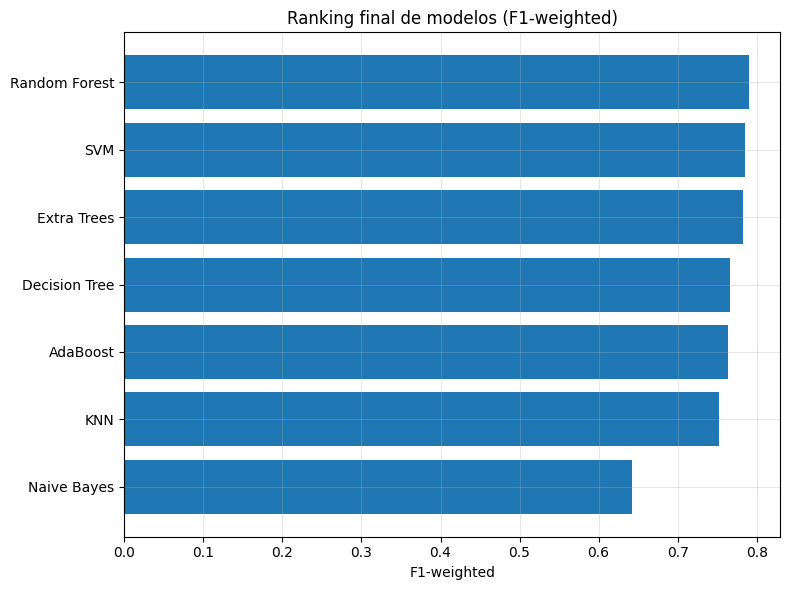

In [94]:
plt.figure(figsize=(8,6))
plt.barh(results["Modelo"], results["F1"])
plt.xlabel("F1-weighted")
plt.title("Ranking final de modelos (F1-weighted)")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


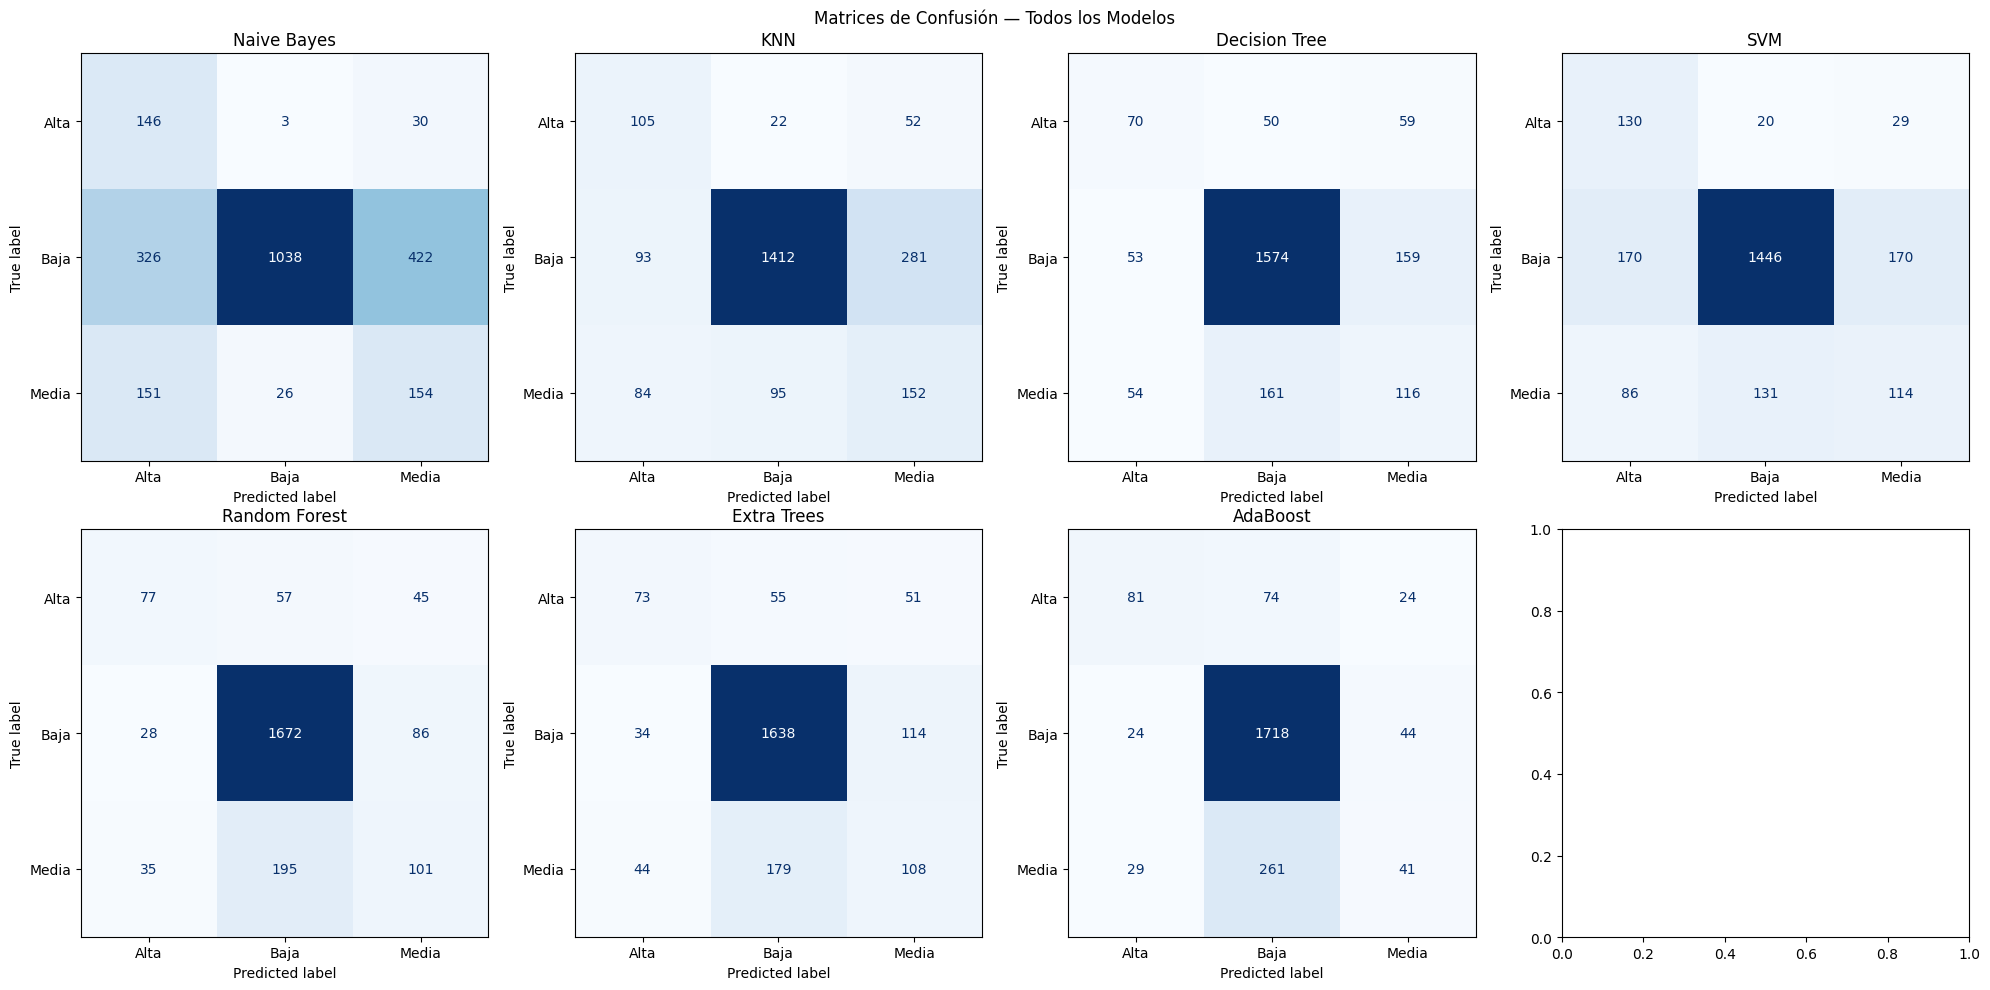

In [96]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_preds = {
    "Naive Bayes": y_pred_nb,
    "KNN": y_pred_knn,
    "Decision Tree": pred_dt,
    "SVM": pred_linear,
    "Random Forest": pred_rf,
    "Extra Trees": pred_et,
    "AdaBoost": pred_ada
}

fig, axes = plt.subplots(2, 4, figsize=(20,10))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, models_preds.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        preds,
        ax=ax,
        cmap="Blues",
        colorbar=False
    )
    ax.set_title(name)

plt.suptitle("Matrices de Confusión — Todos los Modelos")
plt.tight_layout()
plt.show()


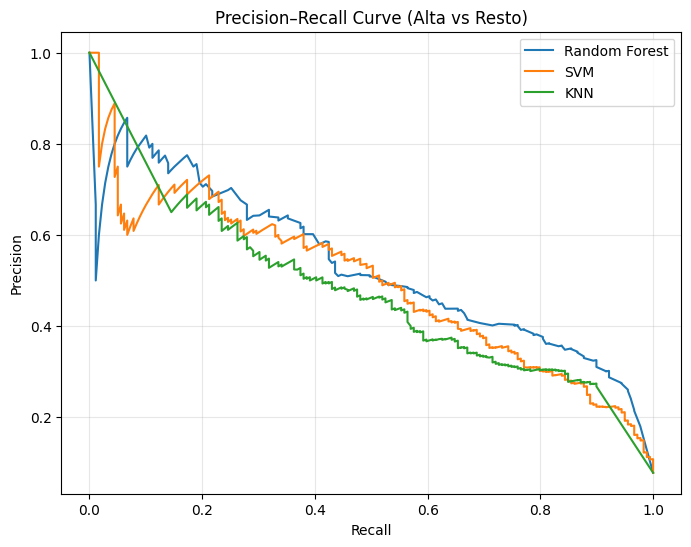

In [97]:
from sklearn.metrics import precision_recall_curve

y_test_bin = (y_test == "Alta").astype(int)

plt.figure(figsize=(8,6))

# Random Forest
probs_rf = rf_final.predict_proba(X_test_tree)[:, list(rf_final.classes_).index("Alta")]
prec, rec, _ = precision_recall_curve(y_test_bin, probs_rf)
plt.plot(rec, prec, label="Random Forest")

# SVM
scores_svm = svm_linear.decision_function(X_test_linear_fs)
idx = list(svm_linear.classes_).index("Alta")
prec, rec, _ = precision_recall_curve(y_test_bin, scores_svm[:, idx])
plt.plot(rec, prec, label="SVM")

# KNN
probs_knn = best_knn.predict_proba(X_test_linear_fs)[:, list(best_knn.classes_).index("Alta")]
prec, rec, _ = precision_recall_curve(y_test_bin, probs_knn)
plt.plot(rec, prec, label="KNN")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Alta vs Resto)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [104]:
train_final = X_train_knn.copy()
train_final["Severidad"] = y_train_knn.values

In [105]:
test_final = X_test_linear_fs.copy()
test_final["Severidad"] = y_test.values

In [106]:
dataset_final = pd.concat([train_final, test_final], axis=0)


In [107]:
dataset_final.to_csv(
    "dataset_preprocessed_best_model_SVM.csv",
    index=False
)
